# Control Variables

Important variables used throughout the code can be changed here.
- `segmentation_window_size`: every signal in a database is sliced into pieces of `segmentation_window_size` seconds to make the signals more comparable
- `tolerance_window_size`: to determine whether a QRS complex was determined correctly a tolerance window of ±`tolerance_window_size` milliseconds is used
- `print_detector_failure`: to decide whether a print should be shown if a detecor failes

In [2]:
segmentation_window_size = 30 # in seconds, default = 30
tolerance_window_size = 150 # in milliseconds, default = 150
max_read_time_minutes = 120 # maximally read 120 minutes of the signal and process it, change to -1 to disable
print_detector_failure = 1 # print detector failure, 1 to print them, 0 to not print them, default = 0
time_all_in_Python = False # desides whether all detectors should be retimed in Python or if detectors may return their own runtime, True to rerun runtime estimation, default = False

import_SIN_from_wfdb = False

## Experiment - Real Databases

Important variables for the real databases experiment are declared and changed here.

In [3]:
evaluate_TELE_database = True # evaluate TELE database, True to evaluate, False to skip evaluation, default = False, evaluation takes long
evaluate_SAFER_database = True # evaluate SAFER database, True to evaluate, False to skip evaluation, default = False, evaluation takes long

# General Setup

## Import Libraries & Start Engines

Install all important libraries with pip apart from `matlab.engine` which has to be installed from the MATLAB root folder. You can find more information on instlaling the `matlab.engine` [here](https://de.mathworks.com/help/matlab/matlab_external/install-the-matlab-engine-for-python.html)

In [4]:
# MATLAB library
import matlab.engine
# general math libraries
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'
#%matplotlib widget
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
from scipy import stats
# other general libraries
import time
import pickle
import os
from os import listdir
from os.path import isfile, join
from itertools import cycle
import pandas
import seaborn as sns 
from statannot import add_stat_annotation
from tol_colors import tol_cmap, tol_cset
# ecg signal and detector libraries
import wfdb
from wfdb import processing
from ecgdetectors import Detectors
from detectors.visgraphdetector import VisGraphDetector
import neurokit2 as nk
from vg_beat_detectors import FastNVG, FastWHVG
from tqdm.notebook import tqdm

In [5]:
from detectors.u3_nc import *
from detectors.dom import dom
from scipy.interpolate import interp1d
from tqdm.notebook import tqdm
from ecg_gudb_database import GUDb
import glob
import re
import os

Start the `matlab.engine` to be able to execute MATLAB commands or functions from within Python.

In [6]:
eng = matlab.engine.start_matlab()

## Other Variables

Create variables with current working directory.

In [7]:
current_working_directory = os.getcwd()
current_working_directory = '/Users/sharonho/Documents/clinical medicine/Y4/SSC/ecg_detector_assessment/Algorithm_tester'
parent_directory = os.path.dirname(current_working_directory)
parent_directory

'/Users/sharonho/Documents/clinical medicine/Y4/SSC/ecg_detector_assessment'

Set general graph settings.

In [8]:
cmap = np.append(matplotlib.colors.to_rgba_array(tol_cset('bright')).tolist()[0:-1], matplotlib.colors.to_rgba_array(tol_cset('light')).tolist(),axis=0).tolist()
flierprops = dict(marker='o', markersize=0.5)
saturation = 1
linewidth = 0.5
linecolor = '0'
capsize = 0.4
errorbar = ("pi", 50)
estimator = np.median

## Define Classes and Functions

`Detector` class to store all values necessary for a detector. This can later be added to a list of `detectors`.

In [9]:
class Detector():
    def __init__(self, name, short_name, algorithm, implementation = None) -> None:
        self.name = name
        self.algorithm = algorithm
        self.short_name = short_name
        self.implementation = implementation
    
    def predicted_qrs_compelx(self, signal, fs):
        return self.algorithm(signal, fs)

    def name(self):
        return self.name

    def short_name(self):
        return self.short_name
    
    def implementation(self):
        return self.implementation

An `Evaluation` gets a `RecordingSegment` or `Recording` described below and the functions `predicted_peaks`, `binary_classification`, and `score_calculation`. The function `calculate` returns the whole element including `predicted_peaks`, number of predicted peaks `pp`, true positives `tp`, false positives `fp`, false negatives `fn`, `sensitivity`, `positive_predictivity`, and the `f1_score`.

In [10]:
class Evaluation():
    def __init__(self, RecordingSegment, Detector, predict_peaks, binary_classification, score_calculation) -> None:
        self.RecordingSegment = RecordingSegment
        self.Detector = Detector
        self.predict_peaks = predict_peaks
        self.binary_classification = binary_classification
        self.score_calculation = score_calculation
        self.predicted_peaks = None # predicted peaks as indexes
        self.runtime = 0
        self.pp = self.tp = self.fp = self.fn = None # number of predicted peaks, true positives, false positives, false negatives respectively
        self.sensitivity = self.positive_predictivity = self.f1_score = None
        self.failed = None
    
    def calculate(self):
        self.predicted_peaks, self.runtime, self.failed = self.predict_peaks(self.RecordingSegment,self.Detector)
        self.pp, self.tp, self.fp, self.fn = self.binary_classification(self.RecordingSegment, self.predicted_peaks)
        self.sensitivity, self.positive_predictivity, self.f1_score = self.score_calculation(self.tp, self.fp, self.fn)
        return self

`Database` class to store all values necessary for a databse. This can later be added to a list of `databases`.

In [11]:
class Database():
    def __init__(self, Name, Users, Fs) -> None:
        self.Name = Name
        self.Users = Users
        self.Fs = Fs

    def Name(self):
        return self.Name

    def Users(self):
        return self.Users

    def Fs(self):
        return self.Fs

Each `Database` stores a list of `Users`. This `User` class stores important information about a user and a list to `Recordings` this user took. `User` can here also be used if a database stores arrythmia and sinus rythm signals.

In [12]:
class User():
    def __init__(self, UserName,Recordings) -> None:
        self.UserName = UserName
        self.Recordings = Recordings

    def UserName(self):
        return self.UserName

    def Recordings(self):
        return self.Recordings

Each `User` stores a list of `Recordings`. This `Recording` class stores important information about a recording and a list to `RecordingSegments` created from the signal in `Recording`. `Recording` stores the whole unsplit signal and list of actual QRS complexes. 

In [13]:
class Recording():
    def __init__(self, RecordingName, RecordingSegments, WholeSignal, WholeActual_Qrs_Complex, Fs, AdditionalInfo = None, Gender = None, Age = -1, Quality = None, AF_SR = None, Mask = None, Experiment = None) -> None:
        self.RecordingName = RecordingName
        self.RecordingSegments = RecordingSegments
        self.WholeSignal = WholeSignal
        self.WholeActual_Qrs_Complex = WholeActual_Qrs_Complex
        self.Fs = Fs
        self.Evaluations = []
        self.AdditionalInfo = AdditionalInfo
        self.Gender = Gender
        self.Age = Age
        self.Quality = Quality
        self.AF_SR = AF_SR
        self.Mask = Mask
        self.Experiment = Experiment

    def RecordingName(self):
        return self.RecordingName
    
    def RecordingSegments(self):
        return self.RecordingSegments

    def WholeSignal(self):
        return self.WholeSignal
    
    def WholeActual_Qrs_Complex(self):
        return self.WholeActual_Qrs_Complex

    def Fs(self):
        return self.Fs

    def Mask(self):
        return self.Mask

    def Gender(self):
        return self.Gender

    def Age(self):
        return self.Age
    
    def Experiment(self):
        return self.Experiment

    def Evaluation(self, detectors, predict_peaks, binary_classification, score_calculation):
        self.Evaluations = []
        for detector in detectors:
            self.Evaluations.append(Evaluation(self,detector,predict_peaks, binary_classification, score_calculation).calculate())
        return self.Evaluations
    
    def addAdditionalInfo(self, AdditionalInfo):
        self.AdditionalInfo = AdditionalInfo

Each `Recording` stores a list of `RecordingSegments`. The `RecordingSegment` class stores important information about a segment of a recording. The function `Evaluation` which takes a list of `detectors` and three functions as an input returns a list of `Evaluation` objects, one for each detector.

In [14]:
class RecordingSegment():
    def __init__(self, Signal, Actual_Qrs_Complex, Fs, AdditionalInfo = None, Mask = None) -> None:
        self.Signal = Signal
        self.Actual_Qrs_Complex = Actual_Qrs_Complex
        self.Fs = Fs
        self.Evaluations = []
        self.AdditionalInfo = AdditionalInfo
        self.Mask = Mask

    def Signal(self):
        return self.Signal

    def Actual_Qrs_Complex(self):
        return self.Actual_Qrs_Complex

    def Fs(self):
        return self.Fs

    def Mask(self):
        return self.Mask

    def Evaluation(self, detectors, predict_peaks, binary_classification, score_calculation):
        self.Evaluations = []
        for detector in detectors:
            self.Evaluations.append(Evaluation(self,detector,predict_peaks, binary_classification, score_calculation).calculate())
        return self.Evaluations

    def addAdditionalInfo(self, AdditionalInfo):
        self.AdditionalInfo = AdditionalInfo

This is a function to split signals in smaller parts including the respecitve qrs complexes. `split_signal` returns an array of arrays where the inner arrays store the signals and the qrs complexes and the outer array stores the inner arrays.

In [15]:
def split_signal(signal, fs, actual_qrs_complexes, mask=None):
    signal = np.array(signal)
    actual_qrs_complexes = np.array(actual_qrs_complexes)
    if mask is not None:
        mask = np.array(mask)
    split = [[] for i in range(((len(signal)//(fs*segmentation_window_size)*2)-1))]

    for split_signal_counter in range((len(signal)//(fs*segmentation_window_size)*2)-1):
        min_index = split_signal_counter*(fs*segmentation_window_size//2)
        max_index = split_signal_counter*(fs*segmentation_window_size//2)+fs*segmentation_window_size-1

        split[split_signal_counter].append(signal[min_index:max_index])

        min_counter = 0
        max_counter = 0

        for qrs_complex_counter in range(len(actual_qrs_complexes)):
            if actual_qrs_complexes[qrs_complex_counter] < min_index:
                min_counter += 1
            if actual_qrs_complexes[qrs_complex_counter] < max_index:
                max_counter += 1
        split[split_signal_counter].append(actual_qrs_complexes[min_counter:max_counter]-min_index)
        if mask is not None:
            split[split_signal_counter].append(mask[min_index:max_index])
        else:
            split[split_signal_counter].append(None)

    return split


## Create Database Objects

### TELE - Telehealth Database
Create a `Database` object for `telehealth_environment_database` including all sub objects necessary to initialize it. The database can be found [here](https://dataverse.harvard.edu/dataset.xhtml?persistentId=doi:10.7910/DVN/QTG0EP).

In [16]:
if evaluate_TELE_database:
    path = join(current_working_directory,'databases/TELE')
    files = [f for f in listdir(path) if isfile(join(path, f))]

    fs = 500
    users = []
    recordings = []
    for file in files:
        if file == 'LICENSE':
            continue
        recordingsegments = []
        data = pandas.read_csv(join(path, file),sep=",",header=None)
        signal = np.array(data[0]).astype(float)
        qrs_complex_indices = np.array(data[1]).astype(int)
        mask = np.array(data[2]).astype(int)
        actual_qrs_complexes = []
        
        for indexcounter in range(len(qrs_complex_indices)):
            if qrs_complex_indices[indexcounter]:
                actual_qrs_complexes.append(indexcounter)
        
        splits = split_signal(signal=signal,fs=fs, actual_qrs_complexes=np.array(actual_qrs_complexes).astype(int), mask=mask)
        
        for split in splits:
            recordingsegments.append(RecordingSegment(Signal=split[0], Actual_Qrs_Complex=split[1], Fs=fs, Mask=split[2]))
        if len(signal) >= segmentation_window_size*fs:
            signal = signal[0:segmentation_window_size*fs]
            actual_qrs_complexes = np.array([qrs for qrs in actual_qrs_complexes if qrs < (segmentation_window_size*fs-1)])
            mask = mask[0:segmentation_window_size*fs]
        recordings.append(Recording(RecordingName=str(file),RecordingSegments = recordingsegments,WholeSignal=signal,WholeActual_Qrs_Complex=actual_qrs_complexes,Fs=fs, Mask=mask))
    users.append(User(UserName="default",Recordings = recordings))   
            
    telehealth_environment_database = Database(
        Name="Telehealth Database",
        Users=users,
        Fs=fs)

### SAFER - SAFER Trial Database
Create a `Database` object for `safer_trial_database` including all sub objects necessary to initialize it. The database is a selection of the [SAFER Trial](https://www.safer.phpc.cam.ac.uk/) dataset.

In [17]:
if evaluate_SAFER_database:
    path = join(current_working_directory,'databases/SAFER/ECGs')
    files = [f[0:-4] for f in listdir(path) if (isfile(join(path, f)) and f.endswith('.atr'))]

    fs = wfdb.rdrecord(join(path,str(files[0])), channels=[0]).fs

    users = []

    data = pandas.read_csv(join(path, 'rec_data_anon.csv'),sep=",")

    for file in files:
        
        measID = int(file[len(file)-6:])
        subject = data[data['measID'] == measID]

        gender = None
        if int(subject['gender']) == 1 : gender = 'F'
        elif int(subject['gender']) == 2 : gender = 'M'

        quality = None
        if int(subject['tag_orig_Poor_Quality']) == 0 : quality = 'HIGH'
        elif int(subject['tag_orig_Poor_Quality']) == 1 : quality = 'LOW'
        
        af_sr = None
        if int(subject['presAF']) == 0 : af_sr = 'nonAF'
        elif int(subject['presAF']) == 1 : af_sr = 'AF'

        age = int(subject['age'])

        ptID = int(subject['ptID'])

        recordings = []
        recordingsegments = []
        signal = np.array(wfdb.rdrecord(join(path,str(file)), channels=[0]).p_signal[:,0]).astype(float)
        actual_qrs_complexes = np.array(wfdb.rdann(join(path,str(file)),'atr').sample[1:]).astype(int)
        comments = np.array(wfdb.rdrecord(join(path,str(file)), channels=[0]).comments)

        splits = split_signal(signal=signal,fs=fs, actual_qrs_complexes=actual_qrs_complexes)
        
        for split in splits:
            recordingsegments.append(RecordingSegment(Signal=split[0], Actual_Qrs_Complex=split[1], Fs=fs))

        if len(signal) >= segmentation_window_size*fs:
            signal = signal[0:segmentation_window_size*fs]
            actual_qrs_complexes = np.array([qrs for qrs in actual_qrs_complexes if qrs < (segmentation_window_size*fs-1)])
        
        #recordings.append(Recording(RecordingName="default",RecordingSegments = recordingsegments,WholeSignal=signal,WholeActual_Qrs_Complex=actual_qrs_complexes,Fs=fs, AdditionalInfo=comments, Gender=gender, Quality = quality, AF_SR = af_sr, Age = age))
        recordings.append(Recording(RecordingName="default",RecordingSegments = recordingsegments,WholeSignal=signal,WholeActual_Qrs_Complex=actual_qrs_complexes,Fs=fs, AdditionalInfo=ptID, Gender=gender, Quality = quality, AF_SR = af_sr, Age = age))
        users.append(User(UserName=str(file),Recordings = recordings))

    safer_trial_database = Database(
        Name="SAFER Trial Database",
        Users=users,
        Fs=fs)

## Create Detector Objects

Create `Detector` objects for detectors from different locations in the standaradized format.

Create `gqrs_detector` object. This detector stems from the wfdb toolbox. More information can be found online.

In [18]:
def run_gqrs_detector(signal, fs):
    predicted_peaks = processing.qrs.gqrs_detect(signal, fs)
    runtime = -1
    return predicted_peaks, runtime

gqrs_detector = Detector(name="GQRS", short_name="gqrs", algorithm=run_gqrs_detector, implementation='Python')

Create `jqrs_detector` object. This detector is written in MATLAB and also executed via the MATLAB engine. Therefore a function has been written to get it into the right format. More information can be found in the respective file.

In [19]:
path = eng.genpath(join(current_working_directory,'detectors\jqrs'))
eng.addpath(path, nargout=0)

def run_jqrs_detector(signal, fs):
    threshold = 0.6 # energy threshold of the detector in au, default = 0.6
    ref_period = 0.250 # refractory period in sec between two R-peaks in ms, default = 0.250
    newsignal = [[i] for i in signal]
    return_val = eng.qrs_detect2(matlab.double(newsignal), threshold, ref_period, matlab.double(fs))
    predicted_peaks =  np.array(return_val['qrs_pos'])[0].astype(int)
    runtime = return_val['runtime'] #np.array(return_val['runtime'])[0].astype(float)
    return predicted_peaks, runtime

jqrs_detector = Detector(name="JQRS", short_name="jqrs", algorithm=run_jqrs_detector, implementation='MATLAB')

Create `visgraph_detector` object. For this detector a Python implementation is used. More information can be found in the respecitve file.

In [20]:
def run_visgraph_detector(signal, fs):
    beta = 0.55 # beta, default = 0.55
    gamma = 0.5 # gamm, default = 0.5
    lowcut = 4 # lowcut, default = 4
    R_peaks, weights, weighted_signal = VisGraphDetector(fs).visgraphdetect(signal, beta=beta, gamma=gamma, lowcut=lowcut, M = 2*fs)
    predicted_peaks = R_peaks
    runtime = -1
    return predicted_peaks, runtime

visgraph_detector = Detector(name="VisGraphDetector", short_name="visgraph", algorithm=run_visgraph_detector, implementation='Python')

Create ```fastnvg_detector``` object. For this detector a Python implementation is used. More information can be found in the respective file.

In [21]:
def run_fastnvg_detector(signal, fs):
    detect = FastNVG(sampling_frequency=fs)
    R_peaks = detect.find_peaks(signal)
    predicted_peaks = R_peaks
    runtime = -1
    return predicted_peaks, runtime

fastnvg_detector = Detector(name="FastNVG", short_name="fastnvg", algorithm=run_fastnvg_detector, implementation='Python')

Create ```fastwhvg_detector``` object. For this detector a Python implementation is used. More information can be found in the respective file.

In [22]:
def run_fastwhvg_detector(signal, fs):
    detect = FastWHVG(sampling_frequency=fs)
    R_peaks = detect.find_peaks(signal)
    predicted_peaks = R_peaks
    runtime = -1
    return predicted_peaks, runtime

fastwhvg_detector = Detector(name="FastWhVG", short_name="fastwhvg", algorithm=run_fastwhvg_detector, implementation='Python')

Create `rpeakdetect_detector` object. This detector is written in MATLAB and also executed via the MATLAB engine. Therefore a function has been written to get it into the right format. More information can be found in the respective file.

In [23]:
path = eng.genpath(join(current_working_directory,'detectors'))
eng.addpath(path, nargout=0)

def run_rpeakdetect_detector(signal, fs):
    threshhold = 0.2 # default = 0.2
    testmode = 0 # default = 0
    newsignal = [[i] for i in signal]
    return_val = eng.rpeakdetect(matlab.double(newsignal), matlab.double(fs),threshhold,testmode)
    predicted_peaks = np.array(return_val['R_index'])[0].astype(int)
    runtime = return_val['runtime'] #np.array(return_val['runtime'])[0].astype(float)
    return predicted_peaks, runtime

rpeakdetect_detector = Detector(name="rpeakdetect", short_name="rpeak", algorithm=run_rpeakdetect_detector, implementation='MATLAB')

Create `r_deco_detector` object. This detector is written in MATLAB and also executed via the MATLAB engine. Therefore a function has been written to get it into the right format. More information can be found in the respective file.

In [24]:
path = eng.genpath(join(current_working_directory,'detectors/r_deco'))
eng.addpath(path, nargout=0)

def run_r_deco_detector(signal, fs):
    envelope_size = 300.0 # envelope size in ms, default = 300.0
    average_heart_rate = 100.0 # average heart rate in bpm, default = 100.0
    post_processing = 1.0 # post processing where 1.0 means yes, default = 1.0
    ectopic_removal = 0.0 # ectopic removal where 1.0 means yes, default = 0.0
    inverted_signal = 0.0 # inverted signal where 1.0 means yes, default = 0.0
    parameters_check = 0.0 # parameters check in UI where 1.0 means yes, default = 0.0
    newsignal = [[i] for i in signal]
    return_val = eng.peak_detection([envelope_size,average_heart_rate,post_processing,ectopic_removal,inverted_signal],matlab.double(newsignal), matlab.double(fs),parameters_check)
    predicted_peaks = np.array(return_val['R_peak'])[0][0].astype(int)
    runtime = return_val['runtime'] #np.array(return_val['runtime'])[0][0].astype(float)
    return predicted_peaks, runtime

r_deco_detector = Detector(name="r_deco", short_name="rdeco", algorithm=run_r_deco_detector, implementation='MATLAB')

Create `unsw_detector` object. This detector is written in MATLAB and also executed via the MATLAB engine. Therefore a function has been written to get it into the right format. More information can be found in the respective file.

In [25]:
path = eng.genpath(join(current_working_directory,'detectors/unsw'))
eng.addpath(path, nargout=0)

def run_unsw_detector(signal, fs):
    mask = [] # mask could be implemented later if wanted
    plotting = False # 1.0 for ploting intermediate signals, 0.0 for no plotting, default = 0.0
    newsignal = [[i] for i in signal]
    return_val = eng.UNSW_QRSDetector(matlab.double(newsignal), matlab.double(fs),matlab.double(mask),bool(plotting))
    predicted_peaks = np.array(return_val['qrs'])[0].astype(int)
    runtime = return_val['runtime'] #np.array(return_val['runtime'])[0].astype(float)
    return predicted_peaks, runtime

unsw_detector = Detector(name="UNSW_QRSDetector", short_name="unsw", algorithm=run_unsw_detector, implementation='MATLAB')

Create functions to get the detectors from the `ecgdetectors` package into the right standard format. Additionally they are safed into their own objects. More information about the package can be found online.

In [26]:
def run_two_average_detector(signal, fs):
    return Detectors(fs).two_average_detector(unfiltered_ecg=signal), -1

two_average_detector = Detector(name="Elgendi et al (Two average)", short_name="two_avg", algorithm=run_two_average_detector, implementation='Python')

def run_matched_filter_detector(signal, fs):
    return Detectors(fs).matched_filter_detector(unfiltered_ecg=signal), -1

matched_filter_detector = Detector(name="Matched filter", short_name="match_fil", algorithm=run_matched_filter_detector, implementation='Python')

def run_swt_detector(signal, fs):
    return Detectors(fs).swt_detector(unfiltered_ecg=signal), -1

swt_detector = Detector(name="Kalidas & Tamil (Wavelet transform)", short_name="swt", algorithm=run_swt_detector, implementation='Python')

def run_engzee_detector(signal, fs):
    return Detectors(fs).engzee_detector(unfiltered_ecg=signal), -1

engzee_detector = Detector(name="Engzee", short_name="engz", algorithm=run_engzee_detector, implementation='Python')

def run_christov_detector(signal, fs):
    return Detectors(fs).christov_detector(unfiltered_ecg=signal), -1

christov_detector = Detector(name="Christov", short_name="christ", algorithm=run_christov_detector, implementation='Python')

def run_hamilton_detector(signal, fs):
    return Detectors(fs).hamilton_detector(unfiltered_ecg=signal), -1

hamilton_detector = Detector(name="Hamilton", short_name="hamilt", algorithm=run_hamilton_detector, implementation='Python')

def run_pan_tompkins_detector(signal, fs):
    return Detectors(fs).pan_tompkins_detector(unfiltered_ecg=signal), -1

pan_tompkins_detector = Detector(name="Pan Tompkins", short_name="pan_tomp", algorithm=run_pan_tompkins_detector, implementation='Python')

def run_wqrs_detector(signal, fs):
    return Detectors(fs).wqrs_detector(unfiltered_ecg=signal), -1

wqrs_detector = Detector(name="WQRS", short_name="wqrs", algorithm=run_wqrs_detector, implementation='Python')

Create functions to get the detectors from the `neurokit2` package into the right standard format. Additionally they are safed into their own objects. More information about the package can be found online.

In [27]:
def run_neurokit(signal, fs):
    # neurokit (default)
    cleaned = nk.ecg_clean(signal, sampling_rate=fs, method="neurokit")
    _, neurokit = nk.ecg_peaks(cleaned, sampling_rate=fs, method="neurokit")
    return neurokit["ECG_R_Peaks"], -1

neurokit_detector = Detector(name="neurokit", short_name="nk", algorithm=run_neurokit, implementation='Python')

def run_pantompkins1985(signal, fs):
    # pantompkins1985
    cleaned = nk.ecg_clean(signal, sampling_rate=fs, method="pantompkins1985")
    _, pantompkins1985 = nk.ecg_peaks(cleaned, sampling_rate=fs, method="pantompkins1985")
    return pantompkins1985["ECG_R_Peaks"], -1

pantompkins1985_detector = Detector(name="pantompkins1985", short_name="pan_tomp_nk", algorithm=run_pantompkins1985, implementation='Python')

def run_nabian2018(signal, fs):
    # nabian2018
    _, nabian2018 = nk.ecg_peaks(signal, sampling_rate=fs, method="nabian2018")
    return nabian2018["ECG_R_Peaks"], -1

nabian2018_detector = Detector(name="nabian2018", short_name="nab_nk", algorithm=run_nabian2018, implementation='Python')

def run_hamilton2002(signal, fs):
    # hamilton2002
    cleaned = nk.ecg_clean(signal, sampling_rate=fs, method="hamilton2002")
    _, hamilton2002 = nk.ecg_peaks(cleaned, sampling_rate=fs, method="hamilton2002")
    return hamilton2002["ECG_R_Peaks"], -1

hamilton2002_detector = Detector(name="hamilton2002", short_name="ham_nk", algorithm=run_hamilton2002, implementation='Python')

def run_martinez2003(signal, fs):
    # martinez2003
    _, martinez2003 = nk.ecg_peaks(signal, sampling_rate=fs, method="martinez2003")
    return martinez2003["ECG_R_Peaks"], -1

martinez2003_detector = Detector(name="martinez2003", short_name="mart_nk", algorithm=run_martinez2003, implementation='Python')

def run_zong2003(signal, fs):
    # zong2003
    _, zong2003 = nk.ecg_peaks(signal, sampling_rate=fs, method="zong2003")
    return zong2003["ECG_R_Peaks"], -1

zong2003_detector = Detector(name="zong2003", short_name="zong_nk", algorithm=run_zong2003, implementation='Python')

def run_christov2004(signal, fs):
    # christov2004
    _, christov2004 = nk.ecg_peaks(signal, sampling_rate=fs, method="christov2004")
    return christov2004["ECG_R_Peaks"], -1

christov2004_detector = Detector(name="christov2004", short_name="chris_nk", algorithm=run_christov2004, implementation='Python')

def run_gamboa2008(signal, fs):
    # gamboa2008
    cleaned = nk.ecg_clean(signal, sampling_rate=fs, method="gamboa2008")
    _, gamboa2008 = nk.ecg_peaks(cleaned, sampling_rate=fs, method="gamboa2008")
    return gamboa2008["ECG_R_Peaks"], -1

gamboa2008_detector = Detector(name="gamboa2008", short_name="gamb_nk", algorithm=run_gamboa2008, implementation='Python')

def run_elgendi2010(signal, fs):
    # elgendi2010
    cleaned = nk.ecg_clean(signal, sampling_rate=fs, method="elgendi2010")
    _, elgendi2010 = nk.ecg_peaks(cleaned, sampling_rate=fs, method="elgendi2010")
    return elgendi2010["ECG_R_Peaks"], -1

elgendi2010_detector = Detector(name="elgendi2010", short_name="elg_nk", algorithm=run_elgendi2010, implementation='Python')

def run_engzeemod2012(signal, fs):
    # engzeemod2012
    cleaned = nk.ecg_clean(signal, sampling_rate=fs, method="engzeemod2012")
    _, engzeemod2012 = nk.ecg_peaks(cleaned, sampling_rate=fs, method="engzeemod2012")
    return engzeemod2012["ECG_R_Peaks"], -1

engzeemod2012_detector = Detector(name="engzeemod2012", short_name="engz_nk", algorithm=run_engzeemod2012, implementation='Python')

def run_kalidas2017(signal, fs):
    # kalidas2017
    cleaned = nk.ecg_clean(signal, sampling_rate=fs, method="kalidas2017")
    _, kalidas2017 = nk.ecg_peaks(cleaned, sampling_rate=fs, method="kalidas2017")
    return kalidas2017["ECG_R_Peaks"], -1

kalidas2017_detector = Detector(name="kalidas2017", short_name="kali_nk", algorithm=run_kalidas2017, implementation='Python')

def run_rodrigues2021(signal, fs):
    # rodrigues2021
    _, rodrigues2021 = nk.ecg_peaks(signal, sampling_rate=fs, method="rodrigues2021")
    return rodrigues2021["ECG_R_Peaks"], -1

rodrigues2021_detector = Detector(name="rodrigues2021", short_name="rodr_nk", algorithm=run_rodrigues2021, implementation='Python')

Try to run the new U3 and DOM under this

In [28]:
def run_u3_detector(signal, fs):
    u3_all, qrs_location_all, signal_filt = u3_transform(signal, fs)
    predicted_peaks = qrs_location_all
    runtime = -1
    return predicted_peaks, runtime

u3_detector = Detector(name="U3Detector", short_name="u3", algorithm=run_u3_detector, implementation='Python')

In [29]:
def run_dom_detector(signal, fs):
    predicted_peaks = dom(signal, fs)
    runtime = -1
    return predicted_peaks, runtime

dom_detector = Detector(name="DOMDetector", short_name="DOM", algorithm=run_dom_detector, implementation='Python')

## Calculation functions

### Predict Peaks Function

The function `predict_peaks` predicts peaks in a signal. It needs a segment which can either be a `RecordingSegment` or a `Recording` and a `Detector` as an input. The output is a vector of predicted peaks.

In [30]:
def predict_peaks(segment, detector_input):
    failed = False

    if isinstance(segment, RecordingSegment):
        signal = segment.Signal
        fs = segment.Fs

    elif isinstance(segment, Recording):
        signal = segment.WholeSignal
        fs = segment.Fs

    else:
        raise Exception('You have to input either a RecordingSegment or a Recording as the segment.')
        
    
    if detector_input.short_name == "match_fil" and (fs != 250 and fs != 360):
        if print_detector_failure:
            failed = True
            print(detector_input.short_name, "could not run because the sample rate is wrong and was skipped")
        return [], 0, failed

    #predicted_peaks = detector.predicted_qrs_compelx(signal=signal, fs=fs)
    start = time.time()
    try:
        predicted_peaks, runtime = detector_input.predicted_qrs_compelx(signal=signal, fs=fs)
    except IndexError:
        if print_detector_failure:
            failed = True
            print(detector_input.short_name, "failed due to an index error and was skipped")
        return [], 0, failed
    except matlab.engine.MatlabExecutionError:
        if print_detector_failure:
            failed = True
            print(detector_input.short_name, "failed due to a MatlabExecutionError, most likely the signal quality was to bad")
        return [], 0, failed
    except OverflowError:
        if print_detector_failure:
            failed = True
            print(detector_input.short_name, "failed due to a Overflow Error, most likely the signal quality was to bad")
        return [], 0, failed
    if runtime == -1 or time_all_in_Python:
        runtime = time.time() - start
    if detector_input.implementation == 'MATLAB':
        pass

    return predicted_peaks, runtime, failed

### Binary Classification Function

The function `binary_classification` classifies whether the predicted peaks are true-positive, false-positive, and false-negative. It needs a segment which can either be a `RecordingSegment` or a `Recording` and a vector of `predicted_peaks` as an input. The output is the number of predicted peaks `pp`, the number of true-positive peaks `tp`, the number of false-positive peaks `fp`, and the number of false-negative peaks `fn`.

In [31]:
def binary_classification(segment, predicted_peaks):

    if isinstance(segment, RecordingSegment):
        actual_peaks = segment.Actual_Qrs_Complex

    elif isinstance(segment, Recording):
        actual_peaks = segment.WholeActual_Qrs_Complex

    else:
        raise Exception('You have to input either a RecordingSegment or a Recording as the segment.')

    mask = segment.Mask

    pp = 0
    tp = 0
    fp = 0
    fn = 0
    
    actual_peaks_iter = actual_peaks

    for predicted_peak in predicted_peaks:
        if mask is not None:
            if mask[predicted_peak]:
                continue
        pp+=1
        tpdetect = 1
        for i in range(len(actual_peaks_iter)):
            if predicted_peak >= (actual_peaks_iter[i] - tolerance_window_size) and predicted_peak <= (actual_peaks_iter[i] + tolerance_window_size):
                tp+=1
                tpdetect = 0
                actual_peaks_iter = np.delete(actual_peaks_iter, i)
                break
        if tpdetect:
            fp+=1

    for actualpeak in actual_peaks_iter:
        fn+=1

    return pp, tp, fp, fn

### Score Calculation Function

Function `score_calculation` to calculate the sensitivity, positive predictivity, and F1-score.

In [32]:
def score_calculation(tp, fp, fn):
    try:
        sensitivity = tp / (tp+fn)
    except ZeroDivisionError:
        sensitivity = 0
    try:
        positive_predictivity = tp / (tp+fp)
    except ZeroDivisionError:
        positive_predictivity = 0
    try:    
        f1_score = tp / (tp+.5*(fp+fn))
    except ZeroDivisionError:
        f1_score = 0
    return sensitivity, positive_predictivity, f1_score

## Add Databases and Detectors

Create arrays to safe the `detectors_base`, `detectors_other` and `databases`.

In [33]:
databases = []
detectors_base = []
detectors_other = []

Add data from different databases to `databases`. By commenting or uncommenting a database here, you can decide whether it should be used in the code.

In [34]:
databases.append(telehealth_environment_database)
databases.append(safer_trial_database)

Add detectors to the `detectors_base` and `detectors_other`. By commenting or uncommenting a detector here, you can decide whether it should be used in the code.

In [35]:
detectors_base.append(two_average_detector)
detectors_base.append(neurokit_detector)
detectors_base.append(unsw_detector)
detectors_other.append(gqrs_detector)
detectors_other.append(jqrs_detector)
detectors_other.append(rpeakdetect_detector)
detectors_other.append(r_deco_detector)
detectors_other.append(wqrs_detector) # differnt implementation of neurokit zong implementation, used because it works, rather slow though
detectors_other.append(kalidas2017_detector) # neurokit detector, same as swt, changed implementation slightly from ecg-detectors package
detectors_other.append(engzee_detector) # same es neurokit engzee implementation but a bit faster even though both refer to the ecg-detectors package
detectors_other.append(christov_detector) # same es neurokit christov implementation but a bit faster even though both refer to the ecg-detectors package
detectors_other.append(hamilton_detector) # same es neurokit hamilton implementation but a bit faster even though both refer to the ecg-detectors package
detectors_other.append(pantompkins1985_detector) # neurokit detector, same as pan_tompkins
detectors_other.append(nabian2018_detector) # neurokit detector, new 
#detectors_other.append(martinez2003_detector) # neurokit detector, new VERY BAD PERFORMANCE
#detectors_other.append(gamboa2008_detector) # neurokit detector, new VERY BAD PERFORMANCE
detectors_other.append(fastnvg_detector) #added after new (faster) version of visgraph_detector was released
detectors_other.append(fastwhvg_detector) #added after new (faster) version of visgraph_detector was released
detectors_other.append(u3_detector)
detectors_other.append(dom_detector)
detectors_other.append(two_average_detector)
detectors_other.append(neurokit_detector)
detectors_other.append(unsw_detector)

`detector_implementation` stores how each algorithm is implemented, either in Pyhton or in MATLAB.

In [36]:
detector_implementation = {
    'gqrs': 'Python',
    'jqrs': 'MATLAB',
    'visgraph': 'Python',
    'rpeak': 'MATLAB',
    'rdeco': 'MATLAB',
    'unsw': 'MATLAB',
    'two-avg': 'Python',
    'match-fil': 'Python',
    'kali': 'Python',
    'engz': 'Python',
    'christ': 'Python',
    'hamilt': 'Python',
    'pan-tomp': 'Python',
    'wqrs': 'Python',
    'nk': 'Python',
    'nab': 'Python',
    'mart': 'Python',
    'zong': 'Python',
    'gamb': 'Python',
    'rodr': 'Python',
    'fnvg' : 'Python',
    'fwhvg' : 'Python',
    'u3': 'Python',
    'DOM': 'Python'
}

`detector_rename` is a dictionary to change the names of the detectors.

In [37]:
detector_rename = {
    'christ':'christ',
    'engz': 'engz',
    'gamb_nk': 'gamb',
    'gqrs': 'gqrs',
    'hamilt': 'hamilt',
    'jqrs': 'jqrs',
    'kali_nk': 'kali',
    'mart_nk': 'mart',
    'nab_nk': 'nab',
    'nk': 'nk',
    'pan_tomp_nk': 'pan-tomp',
    'rdeco': 'rdeco',
    'rpeak': 'rpeak',
    'two_avg': 'two-avg',
    'unsw': 'unsw',
    'wqrs': 'wqrs',
    'fastnvg': 'fnvg',
    'fastwhvg': 'fwhvg',
    'u3': 'u3',
    'DOM': 'dom'
}

`database_rename` stores new names for each database.

In [38]:
database_rename = {
    'Telehealth Database': 'TELE',
    'SAFER Trial Database': 'SAFER',
    'Glasgow Database': 'Glasgow'
}

# Run it as a pair

## Evaluation function for RR intervals - MAE and quality

In [39]:
def get_RR_intervals(base_predicted, other_predicted, ecg_signal, actual_qrs, tolerance_window_size):
    """Obtain the RR intervals of the peak detected by the primary detector, together with the quality assessment. The peak detected by the primary detector is moved to the highest point within the tolerance window to allow the peak to be as close to the top of the QRS complex as possible.

    Args:
        base_predicted (list): predicted indices of the primary detector
        other_predicted (list): predicted indices of the secondary detector
        ecg_signal (NumPy Array): original ECG signal
        actual_qrs (NumPy Array): manual annotations of ECG indices
        tolerance_window_size (integer): tolerance window size
    Returns:
        actual_rr (list): list containing the RR interval and its associated index
        predicted_rr (list): list containing the RR interval and its associated index and quality of the primary detector
        Note: if the annotations are empty, it returns [0],[0]
    """
    quality = []
    # Remove tolerance of primary
    # Initialize a new list to store filtered base_predicted values
    if len(base_predicted) >= 1:
        amplitude_base = ecg_signal[base_predicted]
        filtered_base_predicted = [base_predicted[0]]  # Start with the first value

        # Iterate over the remaining values in both lists simultaneously
        for i in range(1, len(base_predicted)):
            # Check if the current value in base_predicted is at least 150 greater than the last value in the filtered list
            if base_predicted[i] - filtered_base_predicted[-1] > tolerance_window_size:
                # If so, add it to the filtered list
                filtered_base_predicted.append(base_predicted[i])
            else:
                # If the current value is within 150 of the last value, compare their amplitudes
                if amplitude_base[i] > amplitude_base[i - 1]:
                    # If the current value has a higher amplitude, replace the last value in the filtered list
                    filtered_base_predicted[-1] = base_predicted[i]
    else:
        print('base predicted is empty')
        return [0],[0]

    # Remove peaks that are within 150ms of each other in secondary
    if len(other_predicted) >= 1:
        amplitude_other = ecg_signal[other_predicted]
        filtered_other_predicted = [other_predicted[0]]  # Start with the first value

        # Iterate over the remaining values in both lists simultaneously
        for i in range(1, len(other_predicted)):
            # Check if the current value in base_predicted is at least 150 greater than the last value in the filtered list
            if other_predicted[i] - filtered_other_predicted[-1] > tolerance_window_size:
                # If so, add it to the filtered list
                filtered_other_predicted.append(other_predicted[i])
            else:
                # If the current value is within 150 of the last value, compare their amplitudes
                if amplitude_other[i] > amplitude_other[i - 1]:
                    # If the current value has a higher amplitude, replace the last value in the filtered list
                    filtered_other_predicted[-1] = other_predicted[i]
    else:
        print('other predicted is empty')
        return [0],[0]
    # detecting one and only one peak within 150ms of primary
    for i in range(len(filtered_base_predicted)):
        upper_threshold = filtered_base_predicted[i] + tolerance_window_size
        lower_threshold = filtered_base_predicted[i] - tolerance_window_size
        overlap = 0
        for j in range(len(filtered_other_predicted)):
            if filtered_other_predicted[j] <= upper_threshold and filtered_other_predicted[j] >= lower_threshold:
                overlap += 1
            else:
                continue
        if overlap == 1:
            quality.append(1)
        else:
            quality.append(0)
    # no other QRS complexes detected within the RR interval
    actual_rr = []
    for a, b in zip(actual_qrs, actual_qrs[1:]):
        actual_rr.append([b-a, b])

    # Move the peak to the highest position within 50ms
    filtered_base_predicted_max = []
    for i in filtered_base_predicted:
        upper_index = i + 50
        lower_index = i - 50
        if upper_index >= 0 and lower_index >= 0:
            max_index = np.argmax(ecg_signal[lower_index:upper_index])
            filtered_base_predicted_max.append(max_index+i)
        else:
            filtered_base_predicted_max.append(i)
    predicted_rr = []
    for a, b, c, d, e in zip(filtered_base_predicted, filtered_base_predicted[1:], range(len(quality)-1), filtered_base_predicted_max, filtered_base_predicted_max[1:]):
        if quality[c] == 1 and quality[c+1] == 1:
            detected_in_RR = 0
            for i in range(len(filtered_other_predicted)):
                if filtered_other_predicted[i] >= a-tolerance_window_size and filtered_other_predicted[i] <= b+tolerance_window_size:
                    #print(f'{other_predicted_new[i]}>={a-tolerance_window_size} and {other_predicted_new[i]} <= {b+tolerance_window_size}')
                    detected_in_RR += 1
                else:
                    continue
            if detected_in_RR == 2:
                predicted_rr.append([e-d, e, 1])
            else:
                predicted_rr.append([e-d, e, 0])
        else:
            predicted_rr.append([e-d, e, 0])

    
    return actual_rr, predicted_rr

def interpolate_RR(actual_rr, predicted_rr, kind='nearest'):
    """Interpolate RR intervals and resample it to uniform for both the actual RR intervals and that calculated by the primary detector. A mask of the actual RR interval is also applied to reject areas where manually annotated RR intervals exceed 3 seconds

    Args:
        actual_rr (list): list containing the RR interval and its associated index
        predicted_rr (list): list containing the RR interval and its associated index and quality of the primary detector
        kind (string): default is nearest, corresponding to nearest neighbour interpolation
    Returns:
        xnew_actual (list): x coordinates of the RR interval interpolation of the actual RR intervals (time)
        ynew_actual (list): y coordinates of the RR interval interpolation of the actual RR intervals (RR interval)
        xnew_predicted (list): x coordinates of the RR interval interpolation of the RR intervals detected by the primary detector (time)
        ynew_predicted (list): y coordinates of the RR interval interpolation of the RR intervals detected by the primary detector (RR interval)
        quality_predicted (list): interpolation of quality of the predicted RR interval
        mask (list): a binary list which signifies whether the actual RR intervals should be included in the analysis. If the RR interval is larger than 3 seconds, the value will be 0, otherwise it will be 1
        Note: if the inputs are empty, it returns [0],[0],[0],[0],[0],[0]
    """
    if len(actual_rr) <= 1:
        return [0],[0],[0],[0],[0],[0]
    else:
        actual_rr_x = [actual_rr[i][1] for i in range(len(actual_rr))]
        actual_rr_y = [actual_rr[i][0] for i in range(len(actual_rr))]
    if len(predicted_rr) <= 1:
        return [0],[0],[0],[0],[0],[0]
    else:
        predicted_rr_x = [predicted_rr[i][1] for i in range(len(predicted_rr))]
        predicted_rr_y = [predicted_rr[i][0] for i in range(len(predicted_rr))]
        predicted_rr_quality = [predicted_rr[i][2] for i in range(len(predicted_rr))]
    if len(actual_rr_x) > 1: 
        f_actual = interp1d(actual_rr_x, actual_rr_y, kind = kind)
        xnew_actual = np.arange(actual_rr_x[0], actual_rr_x[-1], 1)
        ynew_actual = f_actual(xnew_actual)  
        mask = np.array([0 if num > 3*500 else 1 for num in ynew_actual]) #exclude period where manual annotation >= 3 seconds
    else:
        print('Less than 2 data points for actual')
        return [0],[0],[0],[0],[0],[0]
    if len(predicted_rr_x) > 1:
        f_predicted = interp1d(predicted_rr_x, predicted_rr_y, kind = kind)
        xnew_predicted = np.arange(predicted_rr_x[0], predicted_rr_x[-1], 1)
        ynew_predicted = f_predicted(xnew_predicted)   
        f_quality = interp1d(predicted_rr_x, predicted_rr_quality, kind=kind) 
        quality_predicted = f_quality(xnew_predicted) 
        return xnew_actual, ynew_actual, xnew_predicted, ynew_predicted, quality_predicted, mask
    else:
        print('Less than 2 data points for prediction')
        return [0],[0],[0],[0],[0],[0]

def truncation_RR(xnew_actual, ynew_actual, xnew_predicted, ynew_predicted, quality_predicted):
    """Truncate the RR interval time series to make both actual and predicted the same length. Note that it also truncates the quality segment 
    

    Args:
        xnew_actual (list): x coordinates of the RR interval interpolation of the actual RR intervals (time)
        ynew_actual (list): y coordinates of the RR interval interpolation of the actual RR intervals (RR interval)
        xnew_predicted (list): x coordinates of the RR interval interpolation of the RR intervals detected by the primary detector (time)
        ynew_predicted (list): y coordinates of the RR interval interpolation of the RR intervals detected by the primary detector (RR interval)
        quality_predicted (list): interpolation of quality of the predicted RR interval
    Returns:
        xnew_predicted_truncated (list): truncated version of xnew_predicted
        ynew_predicted_truncated (list): truncated version of ynew_predicted
        xnew_actual_truncated (list): truncated version of xnew_actual
        ynew_actual_truncated (list): truncated version of ynew_actual
        length (integer): The length of the truncated time series
        quality_predicted_truncated (list):
        If there are no overlap, it returns [0],[0],[0],[0],[0]
        If interpolate_RR returns [0],[0],[0],[0],[0] it returns [0],[0],[0],[0],[0]
    """
    #truncation start
    if len(xnew_actual) == 1:
        return [0],[0],[0],[0],[0],[0]
    try:
        if xnew_actual[0] > xnew_predicted[0]:
            predicted_index = np.where(xnew_predicted == xnew_actual[0])[0][0]
            xnew_predicted_truncated_start = xnew_predicted[predicted_index:]
            ynew_predicted_truncated_start = ynew_predicted[predicted_index:]
            quality_predicted_truncated_start = quality_predicted[predicted_index:]
            xnew_actual_truncated_start = xnew_actual
            ynew_actual_truncated_start = ynew_actual

        #if xnew_actual[0] < xnew_predicted[0]:
        else:
            actual_index = np.where(xnew_actual == xnew_predicted[0])[0][0]
            xnew_actual_truncated_start = xnew_actual[actual_index:]
            ynew_actual_truncated_start = ynew_actual[actual_index:]
            xnew_predicted_truncated_start = xnew_predicted
            ynew_predicted_truncated_start = ynew_predicted
            quality_predicted_truncated_start = quality_predicted

        #truncation end
        if xnew_actual_truncated_start[-1] > xnew_predicted_truncated_start[-1]:
            actual_index = np.where(xnew_actual_truncated_start == xnew_predicted_truncated_start[-1])[0][0]
            xnew_actual_truncated = xnew_actual_truncated_start[:actual_index+1]
            ynew_actual_truncated = ynew_actual_truncated_start[:actual_index+1]
            xnew_predicted_truncated = xnew_predicted_truncated_start
            ynew_predicted_truncated = ynew_predicted_truncated_start
            quality_predicted_truncated = quality_predicted_truncated_start
        #if xnew_actual_truncated_start[-1] < xnew_predicted_truncated_start[-1]:
        else:
            predicted_index = np.where(xnew_predicted_truncated_start == xnew_actual_truncated_start[-1])[0][0]
            xnew_predicted_truncated = xnew_predicted_truncated_start[:predicted_index+1]
            ynew_predicted_truncated = ynew_predicted_truncated_start[:predicted_index+1]
            quality_predicted_truncated = quality_predicted_truncated_start[:predicted_index+1]
            xnew_actual_truncated = xnew_actual_truncated_start
            ynew_actual_truncated = ynew_actual_truncated_start
        length = len(xnew_actual_truncated)
        return xnew_predicted_truncated, ynew_predicted_truncated, xnew_actual_truncated, ynew_actual_truncated, length, quality_predicted_truncated
    except IndexError:
        return [0],[0],[0],[0],[0],[0]

def getRRerror(actual_qrs, base_predicted, other_predicted, ecg_signal, kind, tolerance_window_size):
    """Complete analysis function. The mask is applied at this step to ignore the parts where manual annotation results in a RR interval of more than 3 seconds

    Args:
        actual_qrs (NumPy Array): manual annotations of ECG indices
        base_predicted (list): predicted indices of the primary detector
        other_predicted (list): predicted indices of the secondary detector
        ecg_signal (NumPy Array): original ECG signal
        kind (string): type of the interpolation function
        tolerance_window_size (integer): tolerance window size
    Returns:
        mean_abs_error_RR: mean absolute error between the RR intervals from the manually annotated and that of primary detector
        length: length of the truncated time series
        quality_prop: proportion of high quality of the ECG
        Note: if truncation_RR returns [0],[0],[0],[0], it returns None
    """
    actual_rr, predicted_rr = get_RR_intervals(base_predicted, other_predicted, ecg_signal, actual_qrs, tolerance_window_size)
    xnew_actual, ynew_actual, xnew_predicted, ynew_predicted, quality_predicted, mask = interpolate_RR(actual_rr, predicted_rr, kind)
    xnew_predicted_truncated, ynew_predicted_truncated, xnew_actual_truncated, ynew_actual_truncated, length, quality_predicted_truncated = truncation_RR(xnew_actual, ynew_actual, xnew_predicted, ynew_predicted, quality_predicted)
    if len(ynew_actual_truncated) == 1:
        print('RR interval time series has no overlap')
        return np.nan, np.nan, np.nan
    else:
        quality_predicted_truncated_masked = [num for num, element in zip(quality_predicted_truncated, mask) if element == 1]
        ynew_predicted_truncated_masked = np.array([num for num, element in zip(ynew_predicted_truncated, mask) if element == 1])
        ynew_actual_truncated_masked = np.array([num for num, element in zip(ynew_actual_truncated, mask) if element == 1])
        good_quality_index = np.where(np.array(quality_predicted_truncated_masked)==1)[0]
        error_RR = ynew_predicted_truncated_masked[good_quality_index] - ynew_actual_truncated_masked[good_quality_index]
        mean_abs_error_RR = np.mean(np.abs(error_RR))
        quality_prop = np.sum(quality_predicted_truncated_masked)/len(quality_predicted_truncated_masked)
        return mean_abs_error_RR, length, quality_prop





## Functions for analysing overall TELE and SAFER

In [81]:
def obtain_eval(databases, detectors_base, detectors_other):
    """Obtain the predicted peaks by the primary (base) and secondary (other) detectors. It also saves the output as a pickle format

    Args:
        databases (list): Contains the class of databases we want to evaluate in a list
        detectors_base (list): Contains the class of primary detectors we want to evaluate in a list
        detectors_other (list): Contains the class of secondary detectors we want to evaluate in a list

    Returns:
        eval_base_telehealth (list): Predicted peaks of TELE dataset from primary detectors
        eval_other_telehealth (list): Predicted peaks of TELE dataset from secondary detectors
        eval_base_safer (list): Predicted peaks of SAFER dataset from primary detectors
        eval_other_safer (list): Predicted peaks of SAFER dataset from secondary detectors
    """
    eval_base_databases = []
    eval_other_databases = []
    for database in tqdm(databases):
        eval_base_database = []
        eval_other_database = []
        for user in database.Users:
            eval_base_user = []
            eval_other_user = []
            for recording in user.Recordings:
                evaluations_base = recording.Evaluation(detectors_base, predict_peaks, binary_classification, score_calculation)
                base_predicted = []
                other_predicted = []
                for i in range(len(evaluations_base)):
                    base_predicted.append(evaluations_base[i].predicted_peaks)
                evaluations_other = recording.Evaluation(detectors_other, predict_peaks, binary_classification, score_calculation)
                for i in range(len(evaluations_other)):
                    other_predicted.append(evaluations_other[i].predicted_peaks)
                eval_base_user.append(base_predicted)
                eval_other_user.append(other_predicted)
            eval_base_database.append(eval_base_user)
            eval_other_database.append(eval_other_user)
        eval_base_databases.append(eval_base_database)
        eval_other_databases.append(eval_other_database)
    eval_base_telehealth = eval_base_databases[0]
    eval_other_telehealth = eval_other_databases[0]
    eval_base_safer = eval_base_databases[1]
    eval_other_safer = eval_other_databases[1]


    # Specify the path where you want to save the pickle file
    pickle_file_path = f'pairs_evaluation_pickle_new/eval_base_telehealth.pickle'

    # Save the dataset to a pickle file
    with open(pickle_file_path, 'wb') as pickle_file:
        pickle.dump(eval_base_telehealth, pickle_file)

    # Specify the path where you want to save the pickle file
    pickle_file_path = f'pairs_evaluation_pickle_new/eval_other_telehealth.pickle'

    # Save the dataset to a pickle file
    with open(pickle_file_path, 'wb') as pickle_file:
        pickle.dump(eval_other_telehealth, pickle_file)

    # Specify the path where you want to save the pickle file
    pickle_file_path = f'pairs_evaluation_pickle_new/eval_base_safer.pickle'

    # Save the dataset to a pickle file
    with open(pickle_file_path, 'wb') as pickle_file:
        pickle.dump(eval_base_safer, pickle_file)

    # Specify the path where you want to save the pickle file
    pickle_file_path = f'pairs_evaluation_pickle_new/eval_other_safer.pickle'

    # Save the dataset to a pickle file
    with open(pickle_file_path, 'wb') as pickle_file:
        pickle.dump(eval_other_safer, pickle_file)

    return eval_base_telehealth, eval_other_telehealth, eval_base_safer, eval_other_safer


def analysis(eval_base_telehealth, eval_other_telehealth, eval_base_safer, eval_other_safer, tolerance_window_size, kind='nearest'):   
    """Obtain the MAE and quality for each detector pairs for both TELE and SAFER dataset. It also saves the output as a pickle format

    Args:
        eval_base_telehealth (list): Predicted peaks of TELE dataset from primary detectors
        eval_other_telehealth (list): Predicted peaks of TELE dataset from secondary detectors
        eval_base_safer (list): Predicted peaks of SAFER dataset from primary detectors
        eval_other_safer (list) Predicted peaks of SAFER dataset from secondary detectors
        kind (string): interpolation method, default = 'nearest'
        tolerance_window_size (integer): Tolerance window size

    Returns:
        mean_abs_error_RR_all_telehealth (list): MAE of all the detector pairs for all the recordings in TELE dataset
        quality_prop_all_telehealth (list): Quality of all the detector pairs for all the recordings in TELE dataset
        mean_abs_error_RR_all_safer (list): MAE of all the detector pairs for all the recordings in SAFER dataset
        quality_prop_all_safer (list): Quality of all the detector pairs for all the recordings in SAFER dataset
    """
    
    recording_numbers_telehealth = [i for i in range(len(telehealth_environment_database.Users[0].Recordings))]
    actual_qrs_telehealth = []
    ecg_signals_telehealth = []
    for recording_number in range(len(recording_numbers_telehealth)):
        actual_qrs_telehealth.append(telehealth_environment_database.Users[0].Recordings[recording_number].WholeActual_Qrs_Complex)
        ecg_signals_telehealth.append(telehealth_environment_database.Users[0].Recordings[recording_number].WholeSignal)
    eval_base_telehealth_250 = eval_base_telehealth[0]
    eval_other_telehealth_250 = eval_other_telehealth[0]

    mean_abs_error_RR_all_telehealth = []
    length_all_telehealth = []
    quality_prop_all_telehealth = []
    for i in tqdm(range(len(actual_qrs_telehealth))):
        #actual_qrs = actual_qrs_telehealth[i]
        predicted_base_2avg = eval_base_telehealth_250[i][0]
        predicted_base_nk = eval_base_telehealth_250[i][1]
        predicted_base_unsw = eval_base_telehealth_250[i][2]
        predicted_other = eval_other_telehealth_250[i]
        ecg_signal = ecg_signals_telehealth[i]
        ## Calculate 2avg
        mean_abs_error_RR_2avg = []
        length_2avg = []
        quality_prop_2avg = []
        for k in range(len(predicted_other)):
            mean_abs_error_RR, length, quality_prop = getRRerror(actual_qrs_telehealth[i], predicted_base_2avg, predicted_other[k], ecg_signal, kind, tolerance_window_size)
            mean_abs_error_RR_2avg.append(mean_abs_error_RR)
            length_2avg.append(length)
            quality_prop_2avg.append(quality_prop)
        ## Calculate nk
        mean_abs_error_RR_nk = []
        length_nk = []
        quality_prop_nk = []
        for k in range(len(predicted_other)):
            mean_abs_error_RR, length, quality_prop = getRRerror(actual_qrs_telehealth[i], predicted_base_nk, predicted_other[k], ecg_signal, kind, tolerance_window_size)
            mean_abs_error_RR_nk.append(mean_abs_error_RR)
            length_nk.append(length)
            quality_prop_nk.append(quality_prop)
        ## Calculate UNSW
        mean_abs_error_RR_unsw = []
        length_unsw = []
        quality_prop_unsw = []
        for k in range(len(predicted_other)):
            mean_abs_error_RR, length, quality_prop = getRRerror(actual_qrs_telehealth[i], predicted_base_unsw, predicted_other[k], ecg_signal, kind, tolerance_window_size)
            mean_abs_error_RR_unsw.append(mean_abs_error_RR)
            length_unsw.append(length)
            quality_prop_unsw.append(quality_prop)
        ## append into original array
        mean_abs_error_RR_all_telehealth.append([mean_abs_error_RR_2avg,mean_abs_error_RR_nk,mean_abs_error_RR_unsw])
        length_all_telehealth.append([length_2avg, length_nk, length_unsw])
        quality_prop_all_telehealth.append([quality_prop_2avg, quality_prop_nk, quality_prop_unsw])
        
    recording_numbers_safer = [i for i in range(len(safer_trial_database.Users))]
    actual_qrs_safer = []
    ecg_signals_safer = []
    for recording_number in range(len(recording_numbers_safer)):
        actual_qrs_safer.append(safer_trial_database.Users[recording_number].Recordings[0].WholeActual_Qrs_Complex)
        ecg_signals_safer.append(safer_trial_database.Users[recording_number].Recordings[0].WholeSignal)
    mean_abs_error_RR_all_safer = []
    length_all_safer = []
    quality_prop_all_safer = []
    for i in tqdm(range(len(actual_qrs_safer))):
        actual_qrs = actual_qrs_safer[i]
        predicted_base_2avg = eval_base_safer[i][0][0]
        predicted_base_nk = eval_base_safer[i][0][1]
        predicted_base_unsw = eval_base_safer[i][0][2]
        predicted_other = eval_other_safer[i][0]
        ecg_signal = ecg_signals_safer[i]
        ## Calculate 2avg
        mean_abs_error_RR_2avg = []
        length_2avg = []
        quality_prop_2avg = []
        for k in range(len(predicted_other)):
            mean_abs_error_RR, length, quality_prop = getRRerror(actual_qrs_safer[i], predicted_base_2avg, predicted_other[k], ecg_signal, kind, tolerance_window_size)
            mean_abs_error_RR_2avg.append(mean_abs_error_RR)
            length_2avg.append(length)
            quality_prop_2avg.append(quality_prop)
        ## Calculate nk
        mean_abs_error_RR_nk = []
        length_nk = []
        quality_prop_nk = []
        for k in range(len(predicted_other)):
            mean_abs_error_RR, length, quality_prop = getRRerror(actual_qrs_safer[i], predicted_base_nk, predicted_other[k], ecg_signal, kind, tolerance_window_size)
            mean_abs_error_RR_nk.append(mean_abs_error_RR)
            length_nk.append(length)
            quality_prop_nk.append(quality_prop)
        ## Calculate UNSW
        mean_abs_error_RR_unsw = []
        length_unsw = []
        quality_prop_unsw = []
        for k in range(len(predicted_other)):
            mean_abs_error_RR, length, quality_prop = getRRerror(actual_qrs_safer[i], predicted_base_unsw, predicted_other[k], ecg_signal, kind, tolerance_window_size)
            mean_abs_error_RR_unsw.append(mean_abs_error_RR)
            length_unsw.append(length)
            quality_prop_unsw.append(quality_prop)
        ## Append into array
        mean_abs_error_RR_all_safer.append([mean_abs_error_RR_2avg,mean_abs_error_RR_nk,mean_abs_error_RR_unsw])
        length_all_safer.append([length_2avg, length_nk, length_unsw])
        quality_prop_all_safer.append([quality_prop_2avg, quality_prop_nk, quality_prop_unsw])

    # Specify the path where you want to save the pickle file
    pickle_file_path = f'pairs_evaluation_pickle_new/telehealth_MAE_{tolerance_window_size}.pickle'

    # Save the dataset to a pickle file
    with open(pickle_file_path, 'wb') as pickle_file:
        pickle.dump(mean_abs_error_RR_all_telehealth, pickle_file)

    # Specify the path where you want to save the pickle file
    pickle_file_path = f'pairs_evaluation_pickle_new/telehealth_quality_proportion_{tolerance_window_size}.pickle'

    # Save the dataset to a pickle file
    with open(pickle_file_path, 'wb') as pickle_file:
        pickle.dump(quality_prop_all_telehealth, pickle_file) 

    # Specify the path where you want to save the pickle file
    pickle_file_path = f'pairs_evaluation_pickle_new/safer_MAE_{tolerance_window_size}.pickle'

    # Save the dataset to a pickle file
    with open(pickle_file_path, 'wb') as pickle_file:
        pickle.dump(mean_abs_error_RR_all_safer, pickle_file)

    # Specify the path where you want to save the pickle file
    pickle_file_path = f'pairs_evaluation_pickle_new/safer_quality_proportion_{tolerance_window_size}.pickle'

    # Save the dataset to a pickle file
    with open(pickle_file_path, 'wb') as pickle_file:
        pickle.dump(quality_prop_all_safer, pickle_file) 
    
    return  mean_abs_error_RR_all_telehealth,quality_prop_all_telehealth, mean_abs_error_RR_all_safer, quality_prop_all_safer

        
def generate_mean(mean_abs_error_RR_all_telehealth, quality_prop_all_telehealth, mean_abs_error_RR_all_safer, quality_prop_all_safer):
    """Obtain the MAE and quality for each detector pairs for both TELE and SAFER dataset. It also saves the output as a pickle format

    Args:
        mean_abs_error_RR_all_telehealth (list): MAE of all the detector pairs for all the recordings in TELE dataset
        quality_prop_all_telehealth (list): Quality of all the detector pairs for all the recordings in TELE dataset
        mean_abs_error_RR_all_safer (list): MAE of all the detector pairs for all the recordings in SAFER dataset
        quality_prop_all_safer (list): Quality of all the detector pairs for all the recordings in SAFER dataset

    Returns:
        mae_RR_telehealth_all (list): Mean MAE of all the detector pairs across all the recordings in TELE dataset
        quality_prop_telehealth_all (list): Mean quality of all the detector pairs across all the recordings in TELE dataset
        mae_RR_safer_all (list): Mean MAE of all the detector pairs across all the recordings in SAFER dataset
        quality_prop_safer_all (list): Mean quality of all the detector pairs across all the recordings in SAFER dataset
    """
    mae_RR_telehealth_all = []
    mae_RR_telehealth_2avg = []
    mae_RR_telehealth_nk = []
    mae_RR_telehealth_unsw = []
    for i in range(len(mean_abs_error_RR_all_telehealth)):
        sublists_with_none = [sublist for sublist in mean_abs_error_RR_all_telehealth[i] if any(element is None for element in sublist)]
        if len(sublists_with_none) == 0:
            mae_RR_telehealth_2avg.append(np.array(mean_abs_error_RR_all_telehealth[i][0]))
            mae_RR_telehealth_nk.append(np.array(mean_abs_error_RR_all_telehealth[i][1]))
            mae_RR_telehealth_unsw.append(np.array(mean_abs_error_RR_all_telehealth[i][2]))
    mae_RR_telehealth_all.append(np.nanmean(mae_RR_telehealth_2avg, axis=0))
    mae_RR_telehealth_all.append(np.nanmean(mae_RR_telehealth_nk, axis=0))
    mae_RR_telehealth_all.append(np.nanmean(mae_RR_telehealth_unsw, axis=0))

    quality_prop_telehealth_all = []
    quality_prop_telehealth_2avg = []
    quality_prop_telehealth_nk = []
    quality_prop_telehealth_unsw = []
    for i in range(len(quality_prop_all_telehealth)):
        quality_prop_telehealth_2avg.append(np.array(quality_prop_all_telehealth[i][0]))
        quality_prop_telehealth_nk.append(np.array(quality_prop_all_telehealth[i][1]))
        quality_prop_telehealth_unsw.append(np.array(quality_prop_all_telehealth[i][2]))
    quality_prop_telehealth_all.append(np.nanmean(quality_prop_telehealth_2avg, axis=0))
    quality_prop_telehealth_all.append(np.nanmean(quality_prop_telehealth_nk, axis=0))
    quality_prop_telehealth_all.append(np.nanmean(quality_prop_telehealth_unsw, axis=0))

    mae_RR_safer_all = []
    mae_RR_safer_2avg = []
    mae_RR_safer_nk = []
    mae_RR_safer_unsw = []
    for i in range(len(mean_abs_error_RR_all_safer)):
        sublists_with_none = [sublist for sublist in mean_abs_error_RR_all_safer[i] if any(element is None for element in sublist)]
        if len(sublists_with_none) == 0:
            mae_RR_safer_2avg.append(np.array(mean_abs_error_RR_all_safer[i][0]))
            mae_RR_safer_nk.append(np.array(mean_abs_error_RR_all_safer[i][1]))
            mae_RR_safer_unsw.append(np.array(mean_abs_error_RR_all_safer[i][2]))
    mae_RR_safer_all.append(np.nanmean(mae_RR_safer_2avg, axis=0))
    mae_RR_safer_all.append(np.nanmean(mae_RR_safer_nk, axis=0))
    mae_RR_safer_all.append(np.nanmean(mae_RR_safer_unsw, axis=0))

    quality_prop_safer_all = []
    quality_prop_safer_2avg = []
    quality_prop_safer_nk = []
    quality_prop_safer_unsw = []
    for i in range(len(quality_prop_all_safer)):
        quality_prop_safer_2avg.append(np.array(quality_prop_all_safer[i][0]))
        quality_prop_safer_nk.append(np.array(quality_prop_all_safer[i][1]))
        quality_prop_safer_unsw.append(np.array(quality_prop_all_safer[i][2]))
    quality_prop_safer_all.append(np.nanmean(quality_prop_safer_2avg, axis=0))
    quality_prop_safer_all.append(np.nanmean(quality_prop_safer_nk, axis=0))
    quality_prop_safer_all.append(np.nanmean(quality_prop_safer_unsw, axis=0))
    return mae_RR_telehealth_all, quality_prop_telehealth_all, mae_RR_safer_all, quality_prop_safer_all
    
def plot_heatmap(data_all, tolerance_window_size, show_fig, size, square, eval_overall, eval_subgroup):
    """If eval_overall is True, plot heat maps of the Mean MAE and Mean Quality of all detector pairs in both TELE and SAFER dataset. If eval_subgroup is True, plot heat maps of the Mean MAE and Mean Quality of all detector pairs in SAFER subgroup dataset. Note that eval_overall and eval_subgroup cannot be both True in this function. The graphs will be exported in both .svg and .png

    Args:
        data_all (list): Data in a list. Please put it in the format of [mae_RR_telehealth_all, quality_prop_telehealth_all, mae_RR_safer_all, quality_prop_safer_all] if eval_overall and put it in the format of [mae_RR_safer_AF_HIGH_all, quality_prop_safer_AF_HIGH_all, mae_RR_safer_nonAF_HIGH_all, quality_prop_safer_nonAF_HIGH_all, mae_RR_safer_nonAF_LOW_all, quality_prop_safer_nonAF_LOW_all] if eval_subgroup is True
        tolerance_window_size (integer): Tolerance window size
        show_fig (boolean): If True, show the image in the output
        size (tuple): size of the image
        square (boolean): Whether the squares in heatmap is a square
        eval_overall (boolean): If True, evaluate the overall TELE and SAFER dataset
        eval_subgroup (boolean): If True, evaluate SAFER subgroup analysis
        size (tuple): size of figure
    """
    detectors_other_list = [detector_rename[detectors_other[i].short_name] for i in range(len(detectors_other))]
    sorted_indices, detectors_other_list_sorted = zip(*sorted(enumerate(detectors_other_list), key=lambda x: x[1]))
    if eval_overall and eval_subgroup:
        print('separate them this function is stupid and only takes in separate cases lol')
        return None
    for j, dataset in enumerate(data_all):
        data_2avg_mean = [dataset[0][i] for i in sorted_indices]
        data_nk_mean = [dataset[1][i] for i in sorted_indices]
        data_unsw_mean = [dataset[2][i] for i in sorted_indices]
        data = np.vstack((data_2avg_mean, data_nk_mean, data_unsw_mean)).T
        if eval_overall:
            plt.figure(figsize=size)  # Create a new figure for each dataset
            if j == 0:
                sns.heatmap(data, annot=True, fmt=".1f", cbar_kws={'label': 'Mean MAE (ms)'}, square=square)
                plt.title(f'Mean MAE of TELE dataset ({tolerance_window_size})')
                plt.xticks(np.arange(3) + 0.5, [detector_rename[detectors_base[i].short_name] for i in range(len(detectors_base))], rotation=45)
                plt.yticks(np.arange(18) + 0.5, [detectors_other_list_sorted[i] for i in range(len(detectors_other_list))], rotation=0)
                plt.ylabel('Detectors (secondary)')
                plt.xlabel('Detectors (primary)')
                plt.tight_layout()
                plt.savefig(f'pair_plots_new/mae_RR_telehealth_heatmap_sorted_{tolerance_window_size}.svg')
                plt.savefig(f'pair_plots_new/mae_RR_telehealth_heatmap_sorted_{tolerance_window_size}.png', dpi=600)
                if show_fig == False:
                    plt.close()
            elif j == 1:
                sns.heatmap(data*100, annot=True, fmt=".0f", cbar_kws={'label': 'Mean Quality (%)'}, cmap='rocket_r', square=square)
                plt.title(f'Mean Quality of TELE dataset ({tolerance_window_size})')
                plt.xticks(np.arange(3) + 0.5, [detector_rename[detectors_base[i].short_name] for i in range(len(detectors_base))], rotation=45)
                plt.yticks(np.arange(18) + 0.5, [detectors_other_list_sorted[i] for i in range(len(detectors_other_list))], rotation=0)
                plt.ylabel('Detectors (secondary)')
                plt.xlabel('Detectors (primary)')
                plt.tight_layout()
                plt.savefig(f'pair_plots_new/quality_prop_telehealth_heatmap_sorted_{tolerance_window_size}.svg')
                plt.savefig(f'pair_plots_new/quality_prop_telehealth_heatmap_sorted_{tolerance_window_size}.png', dpi=600)
                if show_fig == False:
                    plt.close()
            elif j == 2:
                sns.heatmap(data, annot=True, fmt=".1f", cbar_kws={'label': 'Mean MAE (ms)'}, square=square)
                plt.title(f'Mean MAE of SAFER dataset ({tolerance_window_size})')
                plt.xticks(np.arange(3) + 0.5, [detector_rename[detectors_base[i].short_name] for i in range(len(detectors_base))], rotation=45)
                plt.yticks(np.arange(18) + 0.5, [detectors_other_list_sorted[i] for i in range(len(detectors_other_list))], rotation=0)
                plt.ylabel('Detectors (secondary)')
                plt.xlabel('Detectors (primary)')
                plt.tight_layout()
                plt.savefig(f'pair_plots_new/mae_RR_safer_heatmap_sorted_{tolerance_window_size}.svg')
                plt.savefig(f'pair_plots_new/mae_RR_safer_heatmap_sorted_{tolerance_window_size}.png', dpi=600)
                if show_fig == False:
                    plt.close()
            else:
                sns.heatmap(data*100, annot=True, fmt=".0f", cbar_kws={'label': 'Mean Quality (%)'}, square=square)
                plt.title(f'Mean Quality of SAFER dataset ({tolerance_window_size})')
                plt.xticks(np.arange(3) + 0.5, [detector_rename[detectors_base[i].short_name] for i in range(len(detectors_base))], rotation=45)
                plt.yticks(np.arange(18) + 0.5, [detectors_other_list_sorted[i] for i in range(len(detectors_other_list))], rotation=0)
                plt.ylabel('Detectors (secondary)')
                plt.xlabel('Detectors (primary)')
                plt.tight_layout()
                plt.savefig(f'pair_plots_new/quality_prop_safer_heatmap_sorted_{tolerance_window_size}.svg')
                plt.savefig(f'pair_plots_new/quality_prop_safer_heatmap_sorted_{tolerance_window_size}.png', dpi=600)
                if show_fig == False:
                    plt.close()
        if eval_subgroup:
            plt.figure(figsize=size)
            if j == 0:
                sns.heatmap(data, annot=True, fmt=".1f", cbar_kws={'label': 'Mean MAE (ms)'}, square=square)
                plt.xticks(np.arange(3) + 0.5, [detector_rename[detectors_base[i].short_name] for i in range(len(detectors_base))], rotation=45)
                plt.yticks(np.arange(18) + 0.5, [detectors_other_list_sorted[i] for i in range(len(detectors_other_list))], rotation=0)
                plt.ylabel('Detectors (secondary)')
                plt.xlabel('Detectors (primary)')
                plt.title(f'Mean MAE of SAFER AF-HIGH dataset ({tolerance_window_size})')
                plt.tight_layout()
                # Show the plot
                plt.savefig(f'pair_plots_new/subgroup/mae_RR_safer_AF_HIGH_heatmap_sorted_{tolerance_window_size}.svg')
                plt.savefig(f'pair_plots_new/subgroup/mae_RR_safer_AF_HIGH_heatmap_sorted_{tolerance_window_size}.png', dpi=600)
                if show_fig == False:
                    plt.close()

            if j == 1:
                sns.heatmap(data*100, annot=True, fmt=".0f", cbar_kws={'label': 'Mean Quality (%)'}, cmap='rocket_r', square=square)
                plt.xticks(np.arange(3) + 0.5, [detector_rename[detectors_base[i].short_name] for i in range(len(detectors_base))], rotation=45)
                plt.yticks(np.arange(18) + 0.5, [detectors_other_list_sorted[i] for i in range(len(detectors_other_list))], rotation=0)
                plt.ylabel('Detectors (secondary)')
                plt.xlabel('Detectors (primary)')
                plt.title(f'Mean Quality of SAFER AF-HIGH dataset ({tolerance_window_size})')
                plt.tight_layout()
                # Show the plot
                plt.savefig(f'pair_plots_new/subgroup/quality_prop_safer_AF_HIGH_heatmap_sorted_{tolerance_window_size}.svg')
                plt.savefig(f'pair_plots_new/subgroup/quality_prop_safer_AF_HIGH_heatmap_sorted_{tolerance_window_size}.png', dpi=600)
                if show_fig == False:
                    plt.close()
        
            if j == 2:
                sns.heatmap(data, annot=True, fmt=".1f", cbar_kws={'label': 'Mean MAE (ms)'}, square=square)
                plt.xticks(np.arange(3) + 0.5, [detector_rename[detectors_base[i].short_name] for i in range(len(detectors_base))], rotation=45)
                plt.yticks(np.arange(18) + 0.5, [detectors_other_list_sorted[i] for i in range(len(detectors_other_list))], rotation=0)
                plt.ylabel('Detectors (secondary)')
                plt.xlabel('Detectors (primary)')
                plt.title(f'Mean MAE of SAFER non-AF HIGH dataset ({tolerance_window_size})')
                plt.tight_layout()
                # Show the plot
                plt.savefig(f'pair_plots_new/subgroup/mae_RR_safer_nonAF_HIGH_heatmap_sorted_{tolerance_window_size}.svg')
                plt.savefig(f'pair_plots_new/subgroup/mae_RR_safer_nonAF_HIGH_heatmap_sorted_{tolerance_window_size}.png', dpi=600)
                if show_fig == False:
                    plt.close()
            if j == 3:
                sns.heatmap(data*100, annot=True, fmt=".0f", cbar_kws={'label': 'Mean Quality (%)'}, cmap='rocket_r', square=square)
                plt.xticks(np.arange(3) + 0.5, [detector_rename[detectors_base[i].short_name] for i in range(len(detectors_base))], rotation=45)
                plt.yticks(np.arange(18) + 0.5, [detectors_other_list_sorted[i] for i in range(len(detectors_other_list))], rotation=0)
                plt.ylabel('Detectors (secondary)')
                plt.xlabel('Detectors (primary)')
                plt.title(f'Mean Quality of SAFER non-AF HIGH dataset ({tolerance_window_size})')
                plt.tight_layout()
                # Show the plot
                plt.savefig(f'pair_plots_new/subgroup/quality_prop_safer_nonAF_HIGH_heatmap_sorted_{tolerance_window_size}.svg')
                plt.savefig(f'pair_plots_new/subgroup/quality_prop_safer_nonAF_HIGH_heatmap_sorted_{tolerance_window_size}.png', dpi=600)
                if show_fig == False:
                    plt.close()
            if j == 4:
                sns.heatmap(data, annot=True, fmt=".1f", cbar_kws={'label': 'Mean MAE (ms)'}, square=square)
                plt.xticks(np.arange(3) + 0.5, [detector_rename[detectors_base[i].short_name] for i in range(len(detectors_base))], rotation=45)
                plt.yticks(np.arange(18) + 0.5, [detectors_other_list_sorted[i] for i in range(len(detectors_other_list))], rotation=0)
                plt.ylabel('Detectors (secondary)')
                plt.xlabel('Detectors (primary)')
                plt.title(f'Mean MAE of SAFER non-AF LOW dataset ({tolerance_window_size})')
                plt.tight_layout()
                # Show the plot
                plt.savefig(f'pair_plots_new/subgroup/mae_RR_safer_nonAF_LOW_heatmap_sorted_{tolerance_window_size}.svg')
                plt.savefig(f'pair_plots_new/subgroup/mae_RR_safer_nonAF_LOW_heatmap_sorted_{tolerance_window_size}.png', dpi=600)
                if show_fig == False:
                    plt.close()
            if j == 5:
                sns.heatmap(data*100, annot=True, fmt=".0f", cbar_kws={'label': 'Mean Quality (%)'}, cmap='rocket_r', square=square)
                plt.xticks(np.arange(3) + 0.5, [detector_rename[detectors_base[i].short_name] for i in range(len(detectors_base))], rotation=45)
                plt.yticks(np.arange(18) + 0.5, [detectors_other_list_sorted[i] for i in range(len(detectors_other_list))], rotation=0)
                plt.ylabel('Detectors (secondary)')
                plt.xlabel('Detectors (primary)')
                plt.title(f'Mean Quality of SAFER non-AF LOW dataset ({tolerance_window_size})')
                plt.tight_layout()
                # Show the plot
                plt.savefig(f'pair_plots_new/subgroup/quality_prop_safer_nonAF_LOW_heatmap_sorted_{tolerance_window_size}.svg')
                plt.savefig(f'pair_plots_new/subgroup/quality_prop_safer_nonAF_LOW_heatmap_sorted_{tolerance_window_size}.png', dpi=600)
                if show_fig == False:
                    plt.close()
        
def plot_scatter(data_all, tolerance_window_size, threshold_tele, threshold_safer, threshold_AF_HIGH, threshold_nonAF_HIGH, threshold_nonAF_LOW, annot, eval_overall, eval_subgroup):  
    """If eval_overall is True, plot scatter plot of the Mean MAE against Mean Quality of all detector pairs in both TELE and SAFER dataset. If eval_subgroup is True, plot scatter plot of the Mean MAE against Mean Quality of all detector pairs in SAFER subgroup dataset. Note that eval_overall and eval_subgroup cannot be both True in this function. The graphs will be exported in both .svg and .png

    Args:
        data_all (list): Data in a list. Please put it in the format of [mae_RR_telehealth_all, quality_prop_telehealth_all, mae_RR_safer_all, quality_prop_safer_all] if eval_overall and put it in the format of [mae_RR_safer_AF_HIGH_all, quality_prop_safer_AF_HIGH_all, mae_RR_safer_nonAF_HIGH_all, quality_prop_safer_nonAF_HIGH_all, mae_RR_safer_nonAF_LOW_all, quality_prop_safer_nonAF_LOW_all] if eval_subgroup is True
        tolerance_window_size (integer): Tolerance window size
        threshold_tele (list): Threshold for plotting the top 2 pairs in red for TELE dataset. First element is the MAE threshold and second element is the quality threshold
        threshold_safer (list): Threshold for plotting the top 2 pairs in red for SAFER dataset. First element is the MAE threshold and second element is the quality threshold
        threshold_AF_HIGH (list): Threshold for plotting the top 2 pairs in red for SAFER AF HIGH dataset. First element is the MAE threshold and second element is the quality threshold
        threshold_nonAF_HIGH (list): Threshold for plotting the top 2 pairs in red for SAFER nonAF HIGH dataset. First element is the MAE threshold and second element is the quality threshold
        threshold_nonAF_LOW (list): Threshold for plotting the top 2 pairs in red for SAFER nonAF LOW dataset. First element is the MAE threshold and second element is the quality threshold
        eval_overall (boolean): If True, evaluate the overall TELE and SAFER dataset
        eval_subgroup: If True, evaluate SAFER subgroup analysis
    """
    if eval_overall and eval_subgroup:
        print('separate them this function is stupid and only takes in separate cases lol')
        return None
    all_pairs = []
    a = detectors_base
    b = detectors_other
    for i in range(len(a)):
        for j in range(len(b)):
            if a[i].short_name != b[j].short_name:
                #print([a[i].short_name,b[j].short_name])
                all_pairs.append([a[i].short_name,b[j].short_name])
    if eval_overall:
        mae_RR_telehealth_2avg_scatter = np.delete(data_all[0][0], -3)
        mae_RR_telehealth_nk_scatter = np.delete(data_all[0][1], -2)
        mae_RR_telehealth_unsw_scatter = np.delete(data_all[0][2], -1)
        quality_prop_telehealth_2avg_scatter = np.delete(data_all[1][0], -3)
        quality_prop_telehealth_nk_scatter = np.delete(data_all[1][1], -2)
        quality_prop_telehealth_unsw_scatter = np.delete(data_all[1][2], -1)

        threshold_x_tele, threshold_y_tele = threshold_tele
        data_mae_all_telehealth = np.concatenate([mae_RR_telehealth_2avg_scatter, mae_RR_telehealth_nk_scatter, mae_RR_telehealth_unsw_scatter])
        data_quality_all_telehealth = np.concatenate([quality_prop_telehealth_2avg_scatter, quality_prop_telehealth_nk_scatter, quality_prop_telehealth_unsw_scatter])
        mask = (data_mae_all_telehealth < threshold_x_tele) & (data_quality_all_telehealth > threshold_y_tele)
        # Create a scatter plot with different colors for points in the top-left corner
        plt.figure()
        plt.scatter(data_mae_all_telehealth[~mask], data_quality_all_telehealth[~mask]*100,  color='blue', s=5)  # Points outside top-left corner
        plt.scatter(data_mae_all_telehealth[mask], data_quality_all_telehealth[mask]*100, color='red', s=5)  # Points in top-left corner
        if annot:
            for i, category in enumerate(all_pairs):
                if data_mae_all_telehealth[i] < threshold_x_tele and data_quality_all_telehealth[i] > threshold_y_tele:
                    plt.annotate(category, (data_mae_all_telehealth[i], data_quality_all_telehealth[i]*100), textcoords="offset points", xytext=(5,-10), ha='center', fontsize=10)

        plt.xlabel('Mean MAE (ms)')
        plt.ylabel('Mean Quality (%)')
        plt.title(f'Mean Quality and Mean MAE of TELE dataset ({tolerance_window_size})')
        plt.ylim(-5,105)
        plt.tight_layout()
        plt.savefig(f'pair_plots_new/telehealth_mae_quality_scatter_{tolerance_window_size}.svg')
        plt.savefig(f'pair_plots_new/telehealth_mae_quality_scatter_{tolerance_window_size}.png', dpi=600)

        mae_RR_safer_2avg_scatter = np.delete(data_all[2][0], -3)
        mae_RR_safer_nk_scatter = np.delete(data_all[2][1], -2)
        mae_RR_safer_unsw_scatter = np.delete(data_all[2][2], -1)
        quality_prop_safer_2avg_scatter = np.delete(data_all[3][0], -3)
        quality_prop_safer_nk_scatter = np.delete(data_all[3][1], -2)
        quality_prop_safer_unsw_scatter = np.delete(data_all[3][2], -1)
        colors = np.random.rand(18*3)
        threshold_x_safer, threshold_y_safer = threshold_safer
        data_mae_all_safer = np.concatenate([mae_RR_safer_2avg_scatter, mae_RR_safer_nk_scatter, mae_RR_safer_unsw_scatter])
        data_quality_all_safer = np.concatenate([quality_prop_safer_2avg_scatter, quality_prop_safer_nk_scatter, quality_prop_safer_unsw_scatter])
        mask = (data_mae_all_safer < threshold_x_safer) & (data_quality_all_safer > threshold_y_safer)
        # Create a scatter plot with different colors for points in the top-left corner
        plt.figure()
        plt.scatter(data_mae_all_safer[~mask], data_quality_all_safer[~mask]*100,  color='blue', s=5)  # Points outside top-left corner
        plt.scatter(data_mae_all_safer[mask], data_quality_all_safer[mask]*100, color='red', s=5)  # Points in top-left corner
        if annot:
            for i, category in enumerate(all_pairs):
                if data_mae_all_safer[i] < threshold_x_safer and data_quality_all_safer[i] > threshold_y_safer:
                    plt.annotate(category, (data_mae_all_safer[i], data_quality_all_safer[i]*100), textcoords="offset points", xytext=(5,-10), ha='center', fontsize=10)

        plt.xlabel('Mean MAE (ms)')
        plt.ylabel('Mean Quality (%)')
        plt.title(f'Mean Quality and Mean MAE of SAFER data ({tolerance_window_size})')
        plt.ylim(-5,105)
        plt.tight_layout()
        plt.savefig(f'pair_plots_new/safer_mae_quality_scatter_{tolerance_window_size}.svg')
        plt.savefig(f'pair_plots_new/safer_mae_quality_scatter_{tolerance_window_size}.png', dpi=600)
    if eval_subgroup:


        plt.figure()
        mae_RR_safer_AF_HIGH_2avg_scatter = np.delete(data_all[0][0], -3)
        mae_RR_safer_AF_HIGH_nk_scatter = np.delete(data_all[0][1], -2)
        mae_RR_safer_AF_HIGH_unsw_scatter = np.delete(data_all[0][2], -1)
        quality_prop_safer_AF_HIGH_2avg_scatter = np.delete(data_all[1][0], -3)
        quality_prop_safer_AF_HIGH_nk_scatter = np.delete(data_all[1][1], -2)
        quality_prop_safer_AF_HIGH_unsw_scatter = np.delete(data_all[1][2], -1)
        #scatter
        threshold_x_AF_HIGH, threshold_y_AF_HIGH = threshold_AF_HIGH
        data_mae_all_safer_AF_HIGH = np.concatenate([mae_RR_safer_AF_HIGH_2avg_scatter, mae_RR_safer_AF_HIGH_nk_scatter, mae_RR_safer_AF_HIGH_unsw_scatter])
        data_mae_all_safer_AF_HIGH = np.concatenate([mae_RR_safer_AF_HIGH_2avg_scatter, mae_RR_safer_AF_HIGH_nk_scatter, mae_RR_safer_AF_HIGH_unsw_scatter])
        data_quality_all_safer_AF_HIGH = np.concatenate([quality_prop_safer_AF_HIGH_2avg_scatter, quality_prop_safer_AF_HIGH_nk_scatter, quality_prop_safer_AF_HIGH_unsw_scatter])
        mask = (data_mae_all_safer_AF_HIGH < threshold_x_AF_HIGH) & (data_quality_all_safer_AF_HIGH > threshold_y_AF_HIGH)
        # Create a scatter plot with different colors for points in the top-left corner
        plt.scatter(data_mae_all_safer_AF_HIGH[~mask], data_quality_all_safer_AF_HIGH[~mask]*100,  color='blue', s=5)  # Points outside top-left corner
        plt.scatter(data_mae_all_safer_AF_HIGH[mask], data_quality_all_safer_AF_HIGH[mask]*100, color='red', s=5)  # Points in top-left corner
        if annot:
            for i, category in enumerate(all_pairs):
                if data_mae_all_safer_AF_HIGH[i] < threshold_x_AF_HIGH and data_quality_all_safer_AF_HIGH[i] > threshold_y_AF_HIGH:
                    plt.annotate(category, (data_mae_all_safer_AF_HIGH[i], data_quality_all_safer_AF_HIGH[i]*100), textcoords="offset points", xytext=(5,-10), ha='center', fontsize=10)

        plt.xlabel('Mean MAE (ms)')
        plt.ylabel('Mean Quality (%)')
        plt.title(f'Mean Quality and Mean MAE of SAFER AF-HIGH data ({tolerance_window_size})')
        plt.ylim(-5,105)
        plt.tight_layout()
        plt.savefig(f'pair_plots_new/subgroup/safer_AF_HIGH_mae_quality_scatter_{tolerance_window_size}.svg')
        plt.savefig(f'pair_plots_new/subgroup/safer_AF_HIGH_mae_quality_scatter_{tolerance_window_size}.png', dpi=600)


        plt.figure()
        mae_RR_safer_nonAF_HIGH_2avg_scatter = np.delete(data_all[2][0], -3)
        mae_RR_safer_nonAF_HIGH_nk_scatter = np.delete(data_all[2][1], -2)
        mae_RR_safer_nonAF_HIGH_unsw_scatter = np.delete(data_all[2][2], -1)
        quality_prop_safer_nonAF_HIGH_2avg_scatter = np.delete(data_all[3][0], -3)
        quality_prop_safer_nonAF_HIGH_nk_scatter = np.delete(data_all[3][1], -2)
        quality_prop_safer_nonAF_HIGH_unsw_scatter = np.delete(data_all[3][2], -1)
        #scatter
        threshold_x_nonAF_HIGH, threshold_y_nonAF_HIGH = threshold_nonAF_HIGH
        data_mae_all_safer_nonAF_HIGH = np.concatenate([mae_RR_safer_nonAF_HIGH_2avg_scatter, mae_RR_safer_nonAF_HIGH_nk_scatter, mae_RR_safer_nonAF_HIGH_unsw_scatter])
        data_mae_all_safer_nonAF_HIGH = np.concatenate([mae_RR_safer_nonAF_HIGH_2avg_scatter, mae_RR_safer_nonAF_HIGH_nk_scatter, mae_RR_safer_nonAF_HIGH_unsw_scatter])
        data_quality_all_safer_nonAF_HIGH = np.concatenate([quality_prop_safer_nonAF_HIGH_2avg_scatter, quality_prop_safer_nonAF_HIGH_nk_scatter, quality_prop_safer_nonAF_HIGH_unsw_scatter])
        mask = (data_mae_all_safer_nonAF_HIGH < threshold_x_nonAF_HIGH) & (data_quality_all_safer_nonAF_HIGH > threshold_y_nonAF_HIGH)
        # Create a scatter plot with different colors for points in the top-left corner
        plt.scatter(data_mae_all_safer_nonAF_HIGH[~mask], data_quality_all_safer_nonAF_HIGH[~mask]*100,  color='blue', s=5)  # Points outside top-left corner
        plt.scatter(data_mae_all_safer_nonAF_HIGH[mask], data_quality_all_safer_nonAF_HIGH[mask]*100, color='red', s=5)  # Points in top-left corner
        if annot:
            for i, category in enumerate(all_pairs):
                if data_mae_all_safer_nonAF_HIGH[i] < threshold_x_nonAF_HIGH and data_quality_all_safer_nonAF_HIGH[i] > threshold_y_nonAF_HIGH:
                    plt.annotate(category, (data_mae_all_safer_nonAF_HIGH[i], data_quality_all_safer_nonAF_HIGH[i]*100), textcoords="offset points", xytext=(5,-10), ha='center', fontsize=10)
        plt.xlabel('Mean MAE (ms)')
        plt.ylabel('Mean Quality (%)')
        plt.title(f'Mean Quality and Mean MAE of SAFER non-AF HIGH data ({tolerance_window_size})')
        plt.ylim(-5,105)
        plt.tight_layout()
        plt.savefig(f'pair_plots_new/subgroup/safer_nonAF_HIGH_mae_quality_scatter_{tolerance_window_size}.svg')
        plt.savefig(f'pair_plots_new/subgroup/safer_nonAF_HIGH_mae_quality_scatter_{tolerance_window_size}.png', dpi=600)
        
        mae_RR_safer_nonAF_LOW_2avg_scatter = np.delete(data_all[4][0], -3)
        mae_RR_safer_nonAF_LOW_nk_scatter = np.delete(data_all[4][1], -2)
        mae_RR_safer_nonAF_LOW_unsw_scatter = np.delete(data_all[4][2], -1)
        quality_prop_safer_nonAF_LOW_2avg_scatter = np.delete(data_all[5][0], -3)
        quality_prop_safer_nonAF_LOW_nk_scatter = np.delete(data_all[5][1], -2)
        quality_prop_safer_nonAF_LOW_unsw_scatter = np.delete(data_all[5][2], -1)
        #scatter
        colors = np.random.rand(18*3)
        threshold_x_nonAF_LOW, threshold_y_nonAF_LOW = threshold_nonAF_LOW
        data_mae_all_safer_nonAF_LOW = np.concatenate([mae_RR_safer_nonAF_LOW_2avg_scatter, mae_RR_safer_nonAF_LOW_nk_scatter, mae_RR_safer_nonAF_LOW_unsw_scatter])
        data_mae_all_safer_nonAF_LOW = np.concatenate([mae_RR_safer_nonAF_LOW_2avg_scatter, mae_RR_safer_nonAF_LOW_nk_scatter, mae_RR_safer_nonAF_LOW_unsw_scatter])
        data_quality_all_safer_nonAF_LOW = np.concatenate([quality_prop_safer_nonAF_LOW_2avg_scatter, quality_prop_safer_nonAF_LOW_nk_scatter, quality_prop_safer_nonAF_LOW_unsw_scatter])
        mask = (data_mae_all_safer_nonAF_LOW < threshold_x_nonAF_LOW) & (data_quality_all_safer_nonAF_LOW > threshold_y_nonAF_LOW)
        # Create a scatter plot with different colors for points in the top-left corner
        plt.figure()
        plt.scatter(data_mae_all_safer_nonAF_LOW[~mask], data_quality_all_safer_nonAF_LOW[~mask]*100,  color='blue', s=5)  # Points outside top-left corner
        plt.scatter(data_mae_all_safer_nonAF_LOW[mask], data_quality_all_safer_nonAF_LOW[mask]*100, color='red', s=5)  # Points in top-left corner
        if annot:
            for i, category in enumerate(all_pairs):
                if data_mae_all_safer_nonAF_LOW[i] < threshold_x_nonAF_LOW and data_quality_all_safer_nonAF_LOW[i] > threshold_y_nonAF_LOW:
                    plt.annotate(category, (data_mae_all_safer_nonAF_LOW[i], data_quality_all_safer_nonAF_LOW[i]*100), textcoords="offset points", xytext=(5,-10), ha='center', fontsize=10)

        plt.xlabel('Mean MAE (ms)')
        plt.ylabel('Mean Quality')
        plt.title(f'Mean Quality and Mean MAE of SAFER non-AF LOW data ({tolerance_window_size})')
        plt.ylim(-5,105)
        plt.tight_layout()
        plt.savefig(f'pair_plots_new/subgroup/safer_nonAF_LOW_mae_quality_scatter_{tolerance_window_size}.svg')
        plt.savefig(f'pair_plots_new/subgroup/safer_nonAF_LOW_mae_quality_scatter_{tolerance_window_size}.png', dpi=600)
        
def safer_subgroup(mean_abs_error_RR_all_safer, quality_prop_all_safer):
    """Split MAE and quality into subgroup analysis of nonAF-HIGH, AF-HIGH and nonAF-LOW and obtain the mean value across the recordings

    Args:
        mean_abs_error_RR_all_safer (list): MAE of all recordings for each detector pairs for the whole SAFER dataset
        quality_prop_all_safer (list): quality of all recordings for each detector pairs for the whole SAFER dataset
    Returns:
        mae_RR_safer_AF_HIGH_all (list): Mean MAE across all recordings for each detector pairs for SAFER AF-HIGH
        quality_prop_safer_AF_HIGH_all (list): Mean Quality across all recordings for each detector pairs for SAFER AF-HIGH
        mae_RR_safer_nonAF_HIGH_all (list): Mean MAE across all recordings for each detector pairs for SAFER nonAF-HIGH
        quality_prop_safer_nonAF_HIGH_all (list): Mean Quality across recordings for each detector pairs for SAFER nonAF-HIGH
        mae_RR_safer_nonAF_LOW_all (list): Mean MAE across all recordings for each detector pairs for SAFER nonAF-LOW
        quality_prop_safer_nonAF_LOW_all (list): Mean Quality across all recordings for each detector pairs for SAFER nonAF-LOW
    """
    SAFER_nonAF_HIGH_recordings = []
    SAFER_nonAF_HIGH_index = []
    SAFER_nonAF_LOW_recordings = []
    SAFER_nonAF_LOW_index = []
    SAFER_AF_HIGH_recordings = []
    SAFER_AF_HIGH_index = []
    for user, index in zip(safer_trial_database.Users, range(len(safer_trial_database.Users))):
        for recording in user.Recordings:
            if safer_trial_database.Name == 'SAFER Trial Database':
                if recording.AF_SR == 'nonAF' and recording.Quality == 'HIGH':
                    SAFER_nonAF_HIGH_recordings.append(recording)
                    SAFER_nonAF_HIGH_index.append(index)
                elif recording.AF_SR == 'nonAF' and recording.Quality == 'LOW':
                    SAFER_nonAF_LOW_recordings.append(recording)
                    SAFER_nonAF_LOW_index.append(index)
                elif recording.AF_SR == 'AF' and recording.Quality == 'HIGH':
                    SAFER_AF_HIGH_recordings.append(recording)
                    SAFER_AF_HIGH_index.append(index)
                

    mae_RR_safer_AF_HIGH = [mean_abs_error_RR_all_safer[i] for i in SAFER_AF_HIGH_index]
    quality_safer_AF_HIGH = [quality_prop_all_safer[i] for i in SAFER_AF_HIGH_index]

    mae_RR_safer_nonAF_HIGH = [mean_abs_error_RR_all_safer[i] for i in SAFER_nonAF_HIGH_index]
    quality_safer_nonAF_HIGH = [quality_prop_all_safer[i] for i in SAFER_nonAF_HIGH_index]

    mae_RR_safer_nonAF_LOW = [mean_abs_error_RR_all_safer[i] for i in SAFER_nonAF_LOW_index]
    quality_safer_nonAF_LOW = [quality_prop_all_safer[i] for i in SAFER_nonAF_LOW_index]

    mae_RR_safer_AF_HIGH_all = []
    mae_RR_safer_AF_HIGH_2avg = []
    mae_RR_safer_AF_HIGH_nk = []
    mae_RR_safer_AF_HIGH_unsw = []
    for i in range(len(mae_RR_safer_AF_HIGH)):
        sublists_with_none = [sublist for sublist in mae_RR_safer_AF_HIGH[i] if any(element is None for element in sublist)]
        if len(sublists_with_none) == 0:
            mae_RR_safer_AF_HIGH_2avg.append(np.array(mae_RR_safer_AF_HIGH[i][0]))
            mae_RR_safer_AF_HIGH_nk.append(np.array(mae_RR_safer_AF_HIGH[i][1]))
            mae_RR_safer_AF_HIGH_unsw.append(np.array(mae_RR_safer_AF_HIGH[i][2]))
    mae_RR_safer_AF_HIGH_all.append(np.nanmean(mae_RR_safer_AF_HIGH_2avg, axis=0))
    mae_RR_safer_AF_HIGH_all.append(np.nanmean(mae_RR_safer_AF_HIGH_nk, axis=0))
    mae_RR_safer_AF_HIGH_all.append(np.nanmean(mae_RR_safer_AF_HIGH_unsw, axis=0))

    mae_RR_safer_nonAF_HIGH_all = []
    mae_RR_safer_nonAF_HIGH_2avg = []
    mae_RR_safer_nonAF_HIGH_nk = []
    mae_RR_safer_nonAF_HIGH_unsw = []
    for i in range(len(mae_RR_safer_nonAF_HIGH)):
        sublists_with_none = [sublist for sublist in mae_RR_safer_nonAF_HIGH[i] if any(element is None for element in sublist)]
        if len(sublists_with_none) == 0:
            mae_RR_safer_nonAF_HIGH_2avg.append(np.array(mae_RR_safer_nonAF_HIGH[i][0]))
            mae_RR_safer_nonAF_HIGH_nk.append(np.array(mae_RR_safer_nonAF_HIGH[i][1]))
            mae_RR_safer_nonAF_HIGH_unsw.append(np.array(mae_RR_safer_nonAF_HIGH[i][2]))
    mae_RR_safer_nonAF_HIGH_all.append(np.nanmean(mae_RR_safer_nonAF_HIGH_2avg, axis=0))
    mae_RR_safer_nonAF_HIGH_all.append(np.nanmean(mae_RR_safer_nonAF_HIGH_nk, axis=0))
    mae_RR_safer_nonAF_HIGH_all.append(np.nanmean(mae_RR_safer_nonAF_HIGH_unsw, axis=0))

    mae_RR_safer_nonAF_LOW_all = []
    mae_RR_safer_nonAF_LOW_2avg = []
    mae_RR_safer_nonAF_LOW_nk = []
    mae_RR_safer_nonAF_LOW_unsw = []
    for i in range(len(mae_RR_safer_nonAF_LOW)):
        sublists_with_none = [sublist for sublist in mae_RR_safer_nonAF_LOW[i] if any(element is None for element in sublist)]
        if len(sublists_with_none) == 0:
            mae_RR_safer_nonAF_LOW_2avg.append(np.array(mae_RR_safer_nonAF_LOW[i][0]))
            mae_RR_safer_nonAF_LOW_nk.append(np.array(mae_RR_safer_nonAF_LOW[i][1]))
            mae_RR_safer_nonAF_LOW_unsw.append(np.array(mae_RR_safer_nonAF_LOW[i][2]))
    mae_RR_safer_nonAF_LOW_all.append(np.nanmean(mae_RR_safer_nonAF_LOW_2avg, axis=0))
    mae_RR_safer_nonAF_LOW_all.append(np.nanmean(mae_RR_safer_nonAF_LOW_nk, axis=0))
    mae_RR_safer_nonAF_LOW_all.append(np.nanmean(mae_RR_safer_nonAF_LOW_unsw, axis=0))


    quality_prop_safer_AF_HIGH_all = []
    quality_prop_safer_AF_HIGH_2avg = []
    quality_prop_safer_AF_HIGH_nk = []
    quality_prop_safer_AF_HIGH_unsw = []
    for i in range(len(quality_safer_AF_HIGH)):
        sublists_with_none = [sublist for sublist in quality_safer_AF_HIGH[i] if any(element is None for element in sublist)]
        if len(sublists_with_none) == 0:
            quality_prop_safer_AF_HIGH_2avg.append(np.array(quality_safer_AF_HIGH[i][0]))
            quality_prop_safer_AF_HIGH_nk.append(np.array(quality_safer_AF_HIGH[i][1]))
            quality_prop_safer_AF_HIGH_unsw.append(np.array(quality_safer_AF_HIGH[i][2]))
    quality_prop_safer_AF_HIGH_all.append(np.nanmean(quality_prop_safer_AF_HIGH_2avg, axis=0))
    quality_prop_safer_AF_HIGH_all.append(np.nanmean(quality_prop_safer_AF_HIGH_nk, axis=0))
    quality_prop_safer_AF_HIGH_all.append(np.nanmean(quality_prop_safer_AF_HIGH_unsw, axis=0))

    quality_prop_safer_nonAF_HIGH_all = []
    quality_prop_safer_nonAF_HIGH_2avg = []
    quality_prop_safer_nonAF_HIGH_nk = []
    quality_prop_safer_nonAF_HIGH_unsw = []
    for i in range(len(quality_safer_nonAF_HIGH)):
        sublists_with_none = [sublist for sublist in quality_safer_nonAF_HIGH[i] if any(element is None for element in sublist)]
        if len(sublists_with_none) == 0:
            quality_prop_safer_nonAF_HIGH_2avg.append(np.array(quality_safer_nonAF_HIGH[i][0]))
            quality_prop_safer_nonAF_HIGH_nk.append(np.array(quality_safer_nonAF_HIGH[i][1]))
            quality_prop_safer_nonAF_HIGH_unsw.append(np.array(quality_safer_nonAF_HIGH[i][2]))
    quality_prop_safer_nonAF_HIGH_all.append(np.nanmean(quality_prop_safer_nonAF_HIGH_2avg, axis=0))
    quality_prop_safer_nonAF_HIGH_all.append(np.nanmean(quality_prop_safer_nonAF_HIGH_nk, axis=0))
    quality_prop_safer_nonAF_HIGH_all.append(np.nanmean(quality_prop_safer_nonAF_HIGH_unsw, axis=0))

    quality_prop_safer_nonAF_LOW_all = []
    quality_prop_safer_nonAF_LOW_2avg = []
    quality_prop_safer_nonAF_LOW_nk = []
    quality_prop_safer_nonAF_LOW_unsw = []
    for i in range(len(quality_safer_nonAF_LOW)):
        sublists_with_none = [sublist for sublist in quality_safer_nonAF_LOW[i] if any(element is None for element in sublist)]
        if len(sublists_with_none) == 0:
            quality_prop_safer_nonAF_LOW_2avg.append(np.array(quality_safer_nonAF_LOW[i][0]))
            quality_prop_safer_nonAF_LOW_nk.append(np.array(quality_safer_nonAF_LOW[i][1]))
            quality_prop_safer_nonAF_LOW_unsw.append(np.array(quality_safer_nonAF_LOW[i][2]))
    quality_prop_safer_nonAF_LOW_all.append(np.nanmean(quality_prop_safer_nonAF_LOW_2avg, axis=0))
    quality_prop_safer_nonAF_LOW_all.append(np.nanmean(quality_prop_safer_nonAF_LOW_nk, axis=0))
    quality_prop_safer_nonAF_LOW_all.append(np.nanmean(quality_prop_safer_nonAF_LOW_unsw, axis=0))

    return mae_RR_safer_AF_HIGH_all, quality_prop_safer_AF_HIGH_all, mae_RR_safer_nonAF_HIGH_all, quality_prop_safer_nonAF_HIGH_all, mae_RR_safer_nonAF_LOW_all, quality_prop_safer_nonAF_LOW_all


def complete_all_analysis(eval_base_telehealth, eval_other_telehealth, eval_base_safer, eval_other_safer, threshold_tele, threshold_safer, threshold_AF_HIGH, threshold_nonAF_HIGH, threshold_nonAF_LOW, annot, scatter, show_fig, size, square, kind='nearest'):
    """To complete the whole analysis, including plotting a heat map and a scatter plot"""
    mean_abs_error_RR_all_telehealth,quality_prop_all_telehealth, mean_abs_error_RR_all_safer, quality_prop_all_safer = analysis(eval_base_telehealth, eval_other_telehealth, eval_base_safer, eval_other_safer, tolerance_window_size, kind=kind)
    mae_RR_telehealth_all, quality_prop_telehealth_all, mae_RR_safer_all, quality_prop_safer_all = generate_mean(mean_abs_error_RR_all_telehealth, quality_prop_all_telehealth, mean_abs_error_RR_all_safer, quality_prop_all_safer)
    data_all_overall = [mae_RR_telehealth_all, quality_prop_telehealth_all, mae_RR_safer_all, quality_prop_safer_all]
    plot_heatmap(data_all_overall, tolerance_window_size, show_fig, size, square, eval_overall=True, eval_subgroup=False)
    if scatter:
        plot_scatter(data_all_overall, tolerance_window_size, threshold_tele, threshold_safer, threshold_AF_HIGH, threshold_nonAF_HIGH, threshold_nonAF_LOW, annot, eval_overall = True, eval_subgroup = False)
    mae_RR_safer_AF_HIGH_all, quality_prop_safer_AF_HIGH_all, mae_RR_safer_nonAF_HIGH_all, quality_prop_safer_nonAF_HIGH_all, mae_RR_safer_nonAF_LOW_all, quality_prop_safer_nonAF_LOW_all = safer_subgroup(mean_abs_error_RR_all_safer, quality_prop_all_safer)
    data_all_subgroup = [mae_RR_safer_AF_HIGH_all, quality_prop_safer_AF_HIGH_all, mae_RR_safer_nonAF_HIGH_all, quality_prop_safer_nonAF_HIGH_all, mae_RR_safer_nonAF_LOW_all, quality_prop_safer_nonAF_LOW_all]
    plot_heatmap(data_all_subgroup, tolerance_window_size, show_fig, size, square, eval_overall=False, eval_subgroup=True)
    if scatter:
        plot_scatter(data_all_subgroup, tolerance_window_size, threshold_tele, threshold_safer, threshold_AF_HIGH, threshold_nonAF_HIGH, threshold_nonAF_LOW, annot, eval_overall = False, eval_subgroup = True)
    return data_all_overall, data_all_subgroup






## Evaluations and Graphs

In [268]:
tolerance_window_size_list = [1, 20, 40, 50, 60, 75, 80, 100, 120, 140, 150]
size = (6,6)
square = True
databases = [telehealth_environment_database,safer_trial_database]
threshold_tele = [0,0]
threshold_safer = [0,0]
threshold_AF_HIGH = [0,0]
threshold_nonAF_HIGH = [0,0] 
threshold_nonAF_LOW = [0,0]
# Run in pairs and evaluate if it hasn't been evaluated. If evaluated, files should be in the folder and there's no need to evaluate again
try:
    # Try to open the file
    with open('./pairs_evaluation_pickle_new/eval_base_telehealth.pickle', 'r') as file:
        print('no need to re-run detectors')
        eval_base_telehealth = pd.read_pickle('./pairs_evaluation_pickle_new/eval_base_telehealth.pickle')
        eval_other_telehealth = pd.read_pickle('./pairs_evaluation_pickle_new/eval_other_telehealth.pickle')
        eval_base_safer = pd.read_pickle('./pairs_evaluation_pickle_new/eval_base_safer.pickle')
        eval_other_safer = pd.read_pickle('./pairs_evaluation_pickle_new/eval_other_safer.pickle')
        for tolerance_window_size in tolerance_window_size_list:
            data_all_overall, data_all_subgroup = complete_all_analysis(eval_base_telehealth, eval_other_telehealth, eval_base_safer, eval_other_safer, threshold_tele, threshold_safer, threshold_AF_HIGH, threshold_nonAF_HIGH, threshold_nonAF_LOW, annot = False, scatter = True, show_fig=False, size=size, square=square, kind='nearest')
except FileNotFoundError:
    eval_base_telehealth, eval_other_telehealth, eval_base_safer, eval_other_safer = obtain_eval(databases, detectors_base, detectors_other)
    for tolerance_window_size in tolerance_window_size_list:
        data_all_overall, data_all_subgroup = complete_all_analysis(eval_base_telehealth, eval_other_telehealth, eval_base_safer, eval_other_safer, threshold_tele, threshold_safer, threshold_AF_HIGH, threshold_nonAF_HIGH, threshold_nonAF_LOW, annot = False, scatter = True, show_fig=False, size=size, square=square, kind='nearest')


no need to re-run detectors


  0%|          | 0/250 [00:00<?, ?it/s]

RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series h

c:\Users\sharonho\Anaconda3\envs\ecgbeats\lib\site-packages\numpy\core\fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\sharonho\Anaconda3\envs\ecgbeats\lib\site-packages\numpy\core\_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval tim

  0%|          | 0/507 [00:00<?, ?it/s]

other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval tim

We have decided to use the threshold of 50

no need to re-run detectors


  0%|          | 0/250 [00:00<?, ?it/s]

RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series has no overlap
RR interval time series h

c:\Users\sharonho\Anaconda3\envs\ecgbeats\lib\site-packages\numpy\core\fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\sharonho\Anaconda3\envs\ecgbeats\lib\site-packages\numpy\core\_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval tim

  0%|          | 0/507 [00:00<?, ?it/s]

other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval time series has no overlap
other predicted is empty
RR interval tim

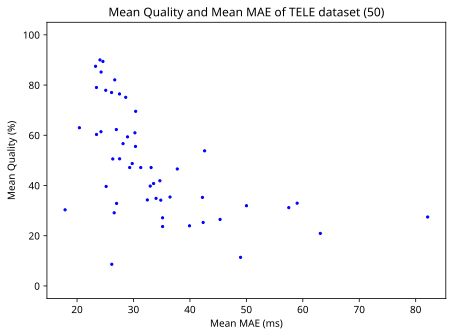

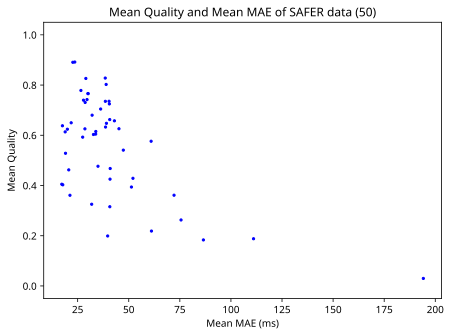

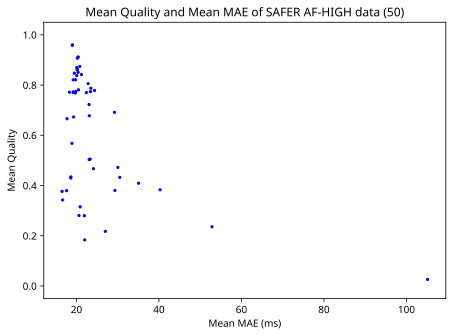

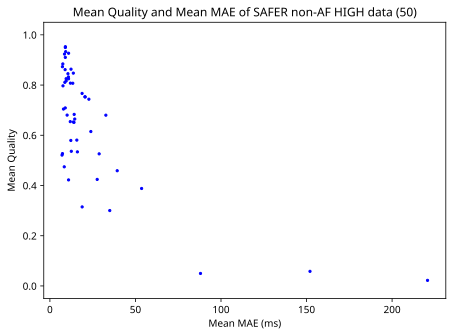

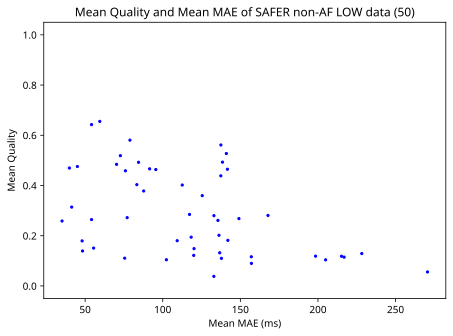

In [41]:
#tolerance_window_size_list = [1, 20, 40, 60, 75, 80, 100, 120, 140, 150]
tolerance_window_size_list = [50]
size = (6,6)
square = True
databases = [telehealth_environment_database,safer_trial_database]
threshold_tele = [0,0]
threshold_safer = [0,0]
threshold_AF_HIGH = [0,0]
threshold_nonAF_HIGH = [0,0] 
threshold_nonAF_LOW = [0,0]
# Run in pairs and evaluate if it hasn't been evaluated. If evaluated, files should be in the folder and there's no need to evaluate again
try:
    # Try to open the file
    with open('./pairs_evaluation_pickle_new/eval_base_telehealth.pickle', 'r') as file:
        print('no need to re-run detectors')
        eval_base_telehealth = pd.read_pickle('./pairs_evaluation_pickle_new/eval_base_telehealth.pickle')
        eval_other_telehealth = pd.read_pickle('./pairs_evaluation_pickle_new/eval_other_telehealth.pickle')
        eval_base_safer = pd.read_pickle('./pairs_evaluation_pickle_new/eval_base_safer.pickle')
        eval_other_safer = pd.read_pickle('./pairs_evaluation_pickle_new/eval_other_safer.pickle')
        for tolerance_window_size in tolerance_window_size_list:
            data_all_overall, data_all_subgroup = complete_all_analysis(eval_base_telehealth, eval_other_telehealth, eval_base_safer, eval_other_safer, threshold_tele, threshold_safer, threshold_AF_HIGH, threshold_nonAF_HIGH, threshold_nonAF_LOW, annot = False, scatter = True, show_fig=False, size=size, square=square, kind='nearest')
except FileNotFoundError:
    eval_base_telehealth, eval_other_telehealth, eval_base_safer, eval_other_safer = obtain_eval(databases, detectors_base, detectors_other)
    for tolerance_window_size in tolerance_window_size_list:
        data_all_overall, data_all_subgroup = complete_all_analysis(eval_base_telehealth, eval_other_telehealth, eval_base_safer, eval_other_safer, threshold_tele, threshold_safer, threshold_AF_HIGH, threshold_nonAF_HIGH, threshold_nonAF_LOW, annot = False, scatter = True, show_fig=False, size=size, square=square, kind='nearest')


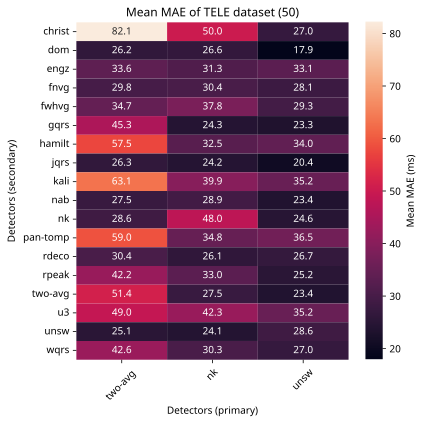

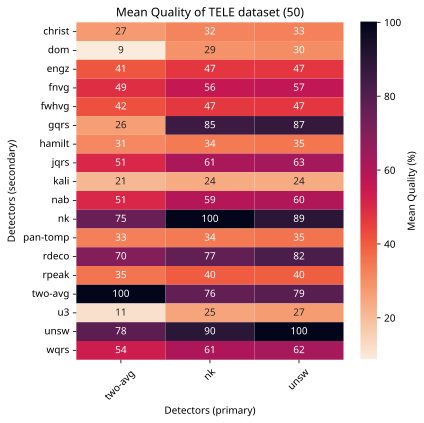

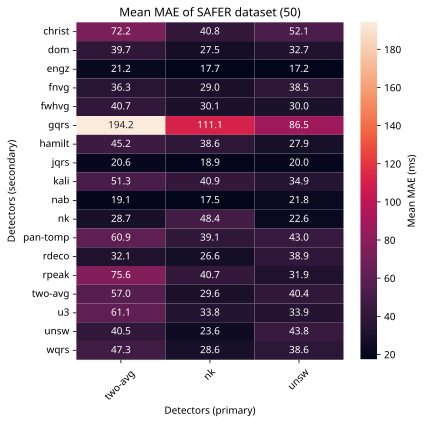

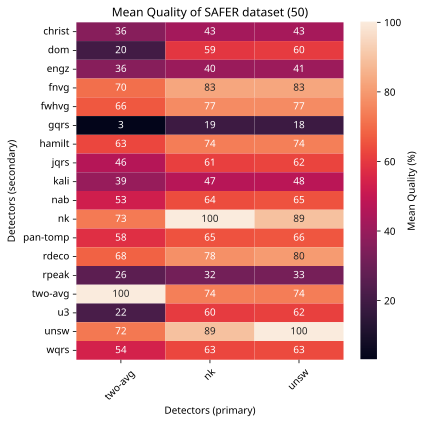

In [82]:
plot_heatmap(data_all_overall, tolerance_window_size, show_fig=True, size=(6,6), square=False, eval_overall=True, eval_subgroup=False)

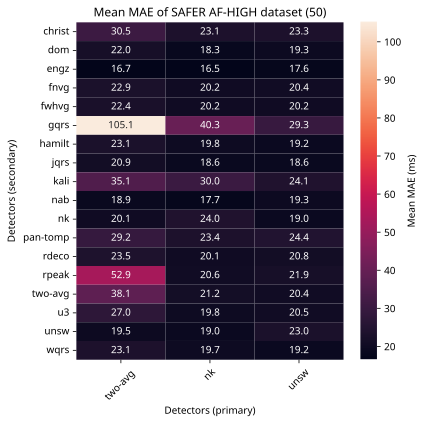

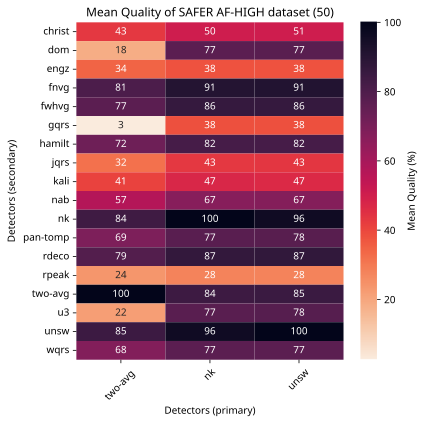

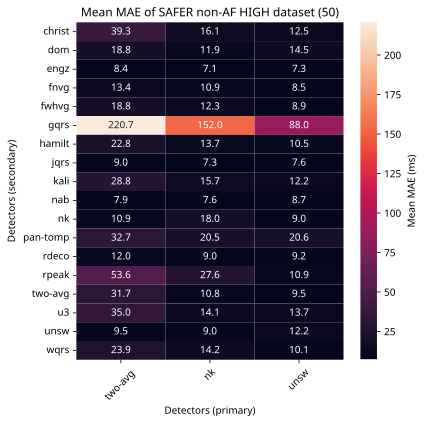

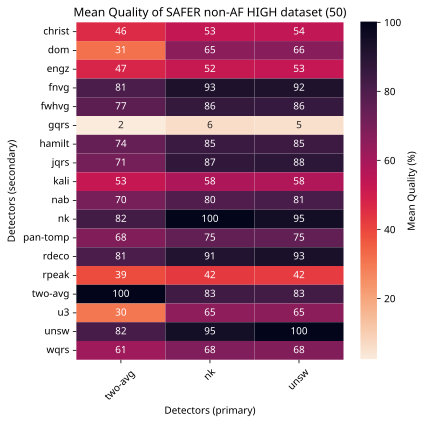

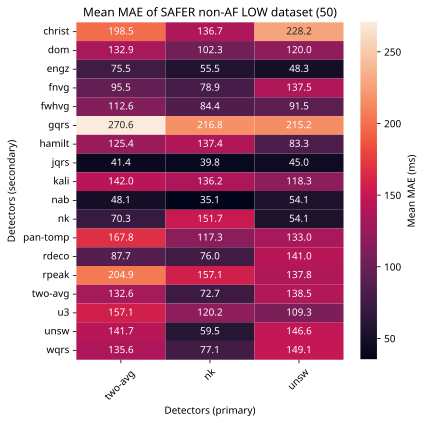

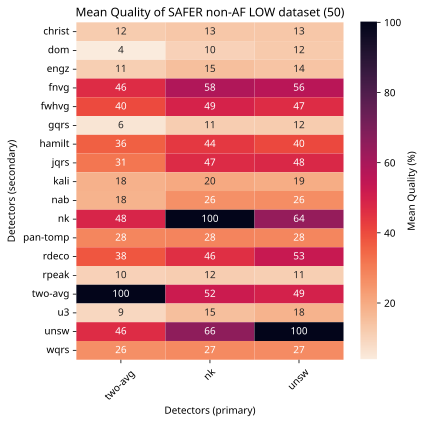

In [70]:
plot_heatmap(data_all_subgroup, tolerance_window_size, show_fig=True, size=(6,6), square=False, eval_overall=False, eval_subgroup=True)

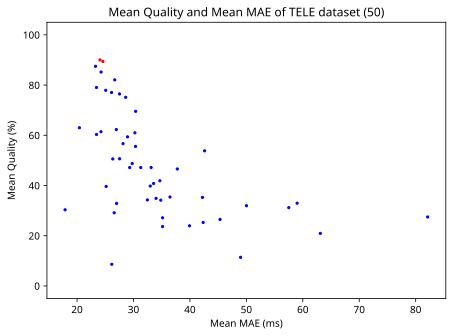

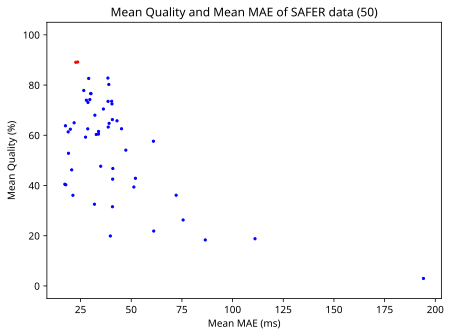

In [79]:
threshold_tele = [25,0.88]
threshold_safer = [30,0.88]
plot_scatter(data_all_overall, tolerance_window_size, threshold_tele, threshold_safer, threshold_AF_HIGH, threshold_nonAF_HIGH, threshold_nonAF_LOW, annot=False, eval_overall = True, eval_subgroup = False)

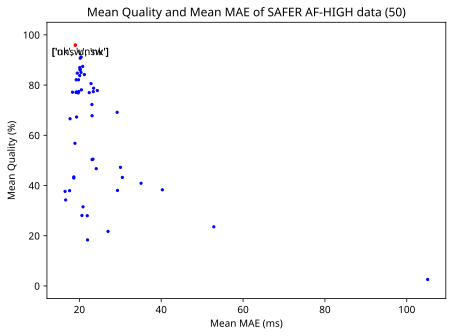

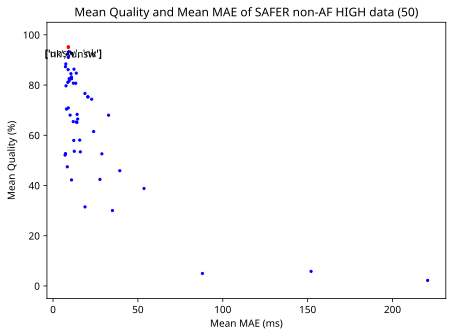

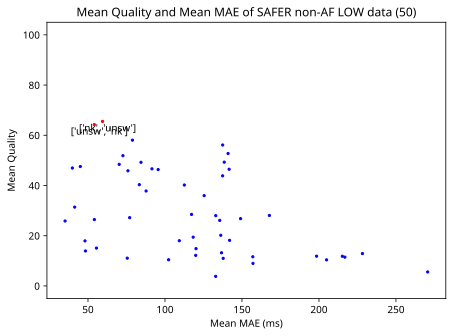

In [85]:
threshold_AF_HIGH = [20,0.88]
threshold_nonAF_HIGH = [20,0.94]
threshold_nonAF_LOW = [75,0.6]
plot_scatter(data_all_subgroup, tolerance_window_size, threshold_tele, threshold_safer, threshold_AF_HIGH, threshold_nonAF_HIGH, threshold_nonAF_LOW, annot=True, eval_overall = False, eval_subgroup = True)

Evaluate the function for [unsw, nk] and [nk, unsw]

In [103]:
def all_quality_mae(tele_mae = True, safer_mae = True, tele_quality = True, safer_quality = True):
    """Read all the pickle files for MAE and quality for different tolerance window sizes

    Args:
        tele_mae (bool): if True, put MAE of TELE into the file
        safer_mae (bool): if True, put MAE of SAFER into the file
        tele_quality (bool): if True, put quality of TELE into the file
        safer_quality (bool): if True, put quality of SAFER into the file
    Returns:
        files (list): contains list of dictionaries of the MAE and quality list from TELE and SAFER. {name of file: file content} In the order of [tele_MAE_all, safer_MAE_all, tele_quality_all, safer_quality_all]
        """
    # Define the directory path where your files are located
    directory_path = './pairs_evaluation_pickle_new/'
    files = []
    if tele_mae:
        file_pattern = directory_path + 'telehealth_MAE_*.pickle'
        file_names = glob.glob(file_pattern)

        # Sort the list of filenames based on the number in the filename
        file_names_sorted = sorted(file_names, key=lambda x: int(x[len(directory_path) + len('telehealth_MAE_'):-len('.pickle')]))
        # Create an empty dictionary to store file contents
        file_contents_telehealth_MAE = {}

        # Iterate over the list of filenames and open each pickle file
        for file_name in file_names_sorted:
            with open(file_name, 'rb') as file:
                # Deserialize the contents of the pickle file
                contents = pickle.load(file)
                # Store the contents in the dictionary with the filename as the key
                file_contents_telehealth_MAE[os.path.splitext(os.path.basename(file_name))[0]] = contents
        files.append(file_contents_telehealth_MAE)
    if safer_mae:
        # Find all files in the directory that match the pattern "SAFER_MAE_*"
        file_pattern = directory_path + 'SAFER_MAE_*.pickle'
        file_names = glob.glob(file_pattern)

        # Sort the list of filenames based on the number in the filename
        file_names_sorted = sorted(file_names, key=lambda x: int(x[len(directory_path) + len('SAFER_MAE_'):-len('.pickle')]))
        # Create an empty dictionary to store file contents
        file_contents_safer_MAE = {}

        # Iterate over the list of filenames and open each pickle file
        for file_name in file_names_sorted:
            with open(file_name, 'rb') as file:
                # Deserialize the contents of the pickle file
                contents = pickle.load(file)
                # Store the contents in the dictionary with the filename as the key
                file_contents_safer_MAE[os.path.splitext(os.path.basename(file_name))[0]] = contents
        files.append(file_contents_safer_MAE)
    if tele_quality:
        file_pattern = directory_path + 'telehealth_quality_proportion_*.pickle'
        file_names = glob.glob(file_pattern)

        # Sort the list of filenames based on the number in the filename
        file_names_sorted = sorted(file_names, key=lambda x: int(x[len(directory_path) + len('telehealth_quality_proportion_'):-len('.pickle')]))
        # Create an empty dictionary to store file contents
        file_contents_telehealth_quality = {}

        # Iterate over the list of filenames and open each pickle file
        for file_name in file_names_sorted:
            with open(file_name, 'rb') as file:
                # Deserialize the contents of the pickle file
                contents = pickle.load(file)
                # Store the contents in the dictionary with the filename as the key
                file_contents_telehealth_quality[os.path.splitext(os.path.basename(file_name))[0]] = contents
        files.append(file_contents_telehealth_quality)
    if safer_quality:
        # Find all files in the directory that match the pattern "SAFER_MAE_*"
        file_pattern = directory_path + 'SAFER_quality_proportion_*.pickle'
        file_names = glob.glob(file_pattern)

        # Sort the list of filenames based on the number in the filename
        file_names_sorted = sorted(file_names, key=lambda x: int(x[len(directory_path) + len('SAFER_quality_proportion_'):-len('.pickle')]))
        # Create an empty dictionary to store file contents
        file_contents_safer_quality = {}

        # Iterate over the list of filenames and open each pickle file
        for file_name in file_names_sorted:
            with open(file_name, 'rb') as file:
                # Deserialize the contents of the pickle file
                contents = pickle.load(file)
                # Store the contents in the dictionary with the filename as the key
                file_contents_safer_quality[os.path.splitext(os.path.basename(file_name))[0]] = contents
        files.append(file_contents_safer_quality)
    return files
    


In [104]:
def mae_quality_tolerances(files):
    """Generate mean MAE and Quality for each detector pair for each tolerance of both TELE and SAFER dataset from a dictionary of files.

    Args:
        files (list): contains list of dictionaries of the MAE and quality list from TELE and SAFER. {name of file: file content} In the order of [tele_MAE_all, safer_MAE_all, tele_quality_all, safer_quality_all]
    Returns:
        mae_RR_telehealth_tolerances (list): Mean MAE for each tolerance for each detector pair for TELE dataset
        quality_prop_telehealth_tolerances (list): Mean Quality for each tolerance for each detector pair for TELE dataset
        mae_RR_safer_tolerances (list): Mean MAE for each tolerance for each detector pair for SAFER dataset
        quality_prop_safer_tolerances (list): Mean Quality for each tolerance for each detector pair for SAFER dataset
        """
    tele_MAE_all = files[0]
    safer_MAE_all = files[1]
    tele_quality_all = files[2]
    safer_quality_all = files[3]
    tele_MAE_key_list = [key for key in tele_MAE_all.keys()]
    safer_MAE_key_list = [key for key in safer_MAE_all.keys()]
    tele_quality_key_list = [key for key in tele_quality_all.keys()]
    safer_quality_key_list = [key for key in safer_quality_all.keys()]
    mae_RR_telehealth_tolerances = []
    quality_prop_telehealth_tolerances = []
    mae_RR_safer_tolerances = []
    quality_prop_safer_tolerances = []
    for i in range(len(tele_MAE_key_list)):
        mae_RR_telehealth, quality_prop_telehealth, mae_RR_safer, quality_prop_safer = generate_mean(tele_MAE_all[tele_MAE_key_list[i]], tele_quality_all[tele_quality_key_list[i]], safer_MAE_all[safer_MAE_key_list[i]], safer_quality_all[safer_quality_key_list[i]], eval_tele=True, eval_safer=True)
        mae_RR_telehealth_tolerances.append(mae_RR_telehealth)
        quality_prop_telehealth_tolerances.append(quality_prop_telehealth)
        mae_RR_safer_tolerances.append(mae_RR_safer)
        quality_prop_safer_tolerances.append(quality_prop_safer)
    return mae_RR_telehealth_tolerances, quality_prop_telehealth_tolerances, mae_RR_safer_tolerances, quality_prop_safer_tolerances

In [112]:
def split_detector(mae_RR_telehealth_tolerances, quality_prop_telehealth_tolerances, mae_RR_safer_tolerances, quality_prop_safer_tolerances, pairs):
    """Generate mean MAE and Quality for each detector pair for each tolerance of both TELE and SAFER dataset from a dictionary of files.

    Args:
        mae_RR_telehealth_tolerances (list): Mean MAE for each tolerance for each detector pair for TELE dataset
        quality_prop_telehealth_tolerances (list): Mean Quality for each tolerance for each detector pair for TELE dataset
        mae_RR_safer_tolerances (list): Mean MAE for each tolerance for each detector pair for SAFER dataset
        quality_prop_safer_tolerances (list): Mean Quality for each tolerance for each detector pair for SAFER dataset
        pairs: detector pairs that we want to evaluate [{index of primary detector}, {index of secondary detector}]
    Returns:
        telehealth_mae_tolerances_pairs (list): Mean MAE of specific pairs for all tolerances for TELE dataset
        safer_mae_tolerances_pairs (list): Mean MAE of specific pairs for all tolerances for SAFER dataset
        telehealth_quality_tolerances_pairs (list): Mean Quality of specific pairs for all tolerances for TELE dataset
        safer_quality_tolerances_pairs (list): Mean Quality of specific pairs for all tolerances for SAFER dataset
        """
    telehealth_mae_tolerances_pairs = []
    safer_mae_tolerances_pairs = []
    telehealth_quality_tolerances_pairs = []
    safer_quality_tolerances_pairs = []
    for j in range(len(pairs)):
        telehealth_mae_tolerances = []
        safer_mae_tolerances = []
        telehealth_quality_tolerances = []
        safer_quality_tolerances = []
        for i in range(len(quality_prop_telehealth_tolerances)):
            telehealth_mae_tolerances.append(mae_RR_telehealth_tolerances[i][pairs[j][0]][pairs[j][1]])
            safer_mae_tolerances.append(mae_RR_safer_tolerances[i][pairs[j][0]][pairs[j][1]])
            telehealth_quality_tolerances.append(quality_prop_telehealth_tolerances[i][pairs[j][0]][pairs[j][1]])
            safer_quality_tolerances.append(quality_prop_safer_tolerances[i][pairs[j][0]][pairs[j][1]])
        telehealth_mae_tolerances_pairs.append(telehealth_mae_tolerances)
        safer_mae_tolerances_pairs.append(safer_mae_tolerances)
        telehealth_quality_tolerances_pairs.append(telehealth_quality_tolerances)
        safer_quality_tolerances_pairs.append(safer_quality_tolerances)
    return telehealth_mae_tolerances_pairs, safer_mae_tolerances_pairs, telehealth_quality_tolerances_pairs, safer_quality_tolerances_pairs

    

In [134]:
def plot_mae_quality_function(telehealth_mae_tolerances_pairs, safer_mae_tolerances_pairs, telehealth_quality_tolerances_pairs, safer_quality_tolerances_pairs, pairs, detectors_base, detectors_other, tolerance_window_size_list, show_fig):
    for i in range(len(pairs)):
        plt.figure()
        # Create figure and axis objects
        fig, ax1 = plt.subplots()

        # Plot data on the first y-axis
        ax1.plot(tolerance_window_size_list, telehealth_mae_tolerances_pairs[i], color='r')
        ax1.set_ylabel('MAE', color='r')
        ax1.set_xlabel('tolerance window size')

        # Create a twin y-axis sharing the same x-axis
        ax2 = ax1.twinx()

        # Plot data on the second y-axis
        ax2.plot(tolerance_window_size_list, np.array(telehealth_quality_tolerances_pairs[i])*100, color='b')
        ax2.set_ylabel('Quality (%)', color='b')
        ax2.set_ylim(0,100)

        plt.title(f'Telehealth ([{detectors_base[pairs[i][0]].short_name}, {detectors_other[pairs[i][1]].short_name}])')
        plt.savefig(f'./pair_plots_new/function/tele_function_{detectors_base[pairs[i][0]].short_name}_{detectors_other[pairs[i][1]].short_name}.svg')
        plt.savefig(f'./pair_plots_new/function/tele_function_{detectors_base[pairs[i][0]].short_name}_{detectors_other[pairs[i][1]].short_name}.png', dpi=600)
        
        if show_fig == False:
            plt.close(fig)
            
        plt.figure()
        # Create figure and axis objects
        fig, ax1 = plt.subplots()

        # Plot data on the first y-axis
        ax1.plot(tolerance_window_size_list, safer_mae_tolerances_pairs[i], color='r')
        ax1.set_ylabel('MAE', color='r')
        ax1.set_xlabel('tolerance window size')

        # Create a twin y-axis sharing the same x-axis
        ax2 = ax1.twinx()

        # Plot data on the second y-axis
        ax2.plot(tolerance_window_size_list, np.array(safer_quality_tolerances_pairs[i])*100, color='b')
        ax2.set_ylabel('Quality (%)', color='b')
        ax2.set_ylim(0,100)

        plt.title(f'SAFER ([{detectors_base[pairs[i][0]].short_name}, {detectors_other[pairs[i][1]].short_name}])')
        plt.savefig(f'./pair_plots_new/function/safer_function_{detectors_base[pairs[i][0]].short_name}_{detectors_other[pairs[i][1]].short_name}.svg')
        plt.savefig(f'./pair_plots_new/function/safer_function_{detectors_base[pairs[i][0]].short_name}_{detectors_other[pairs[i][1]].short_name}.png', dpi=600)

        if show_fig == False:
            plt.close(fig)

In [132]:
list1 = [0, 1, 2]
list2 = list(range(18))

# Create an empty list to store combinations
combinations = []

# Iterate over each element in list1
for num1 in list1:
    # Iterate over each element in list2
    for num2 in list2:
        # Append the combination of num1 and num2 to the combinations list
        combinations.append((num1, num2))

print(combinations)

[(0, 0), (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 9), (0, 10), (0, 11), (0, 12), (0, 13), (0, 14), (0, 15), (0, 16), (0, 17), (1, 0), (1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8), (1, 9), (1, 10), (1, 11), (1, 12), (1, 13), (1, 14), (1, 15), (1, 16), (1, 17), (2, 0), (2, 1), (2, 2), (2, 3), (2, 4), (2, 5), (2, 6), (2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12), (2, 13), (2, 14), (2, 15), (2, 16), (2, 17)]


In [ ]:
pairs = combinations
tolerance_window_size_list = [1, 20, 40, 60, 75, 80, 100, 120, 140, 150]
files = all_quality_mae(tele_mae = True, safer_mae = True, tele_quality = True, safer_quality = True)
mae_RR_telehealth_tolerances, quality_prop_telehealth_tolerances, mae_RR_safer_tolerances, quality_prop_safer_tolerances = mae_quality_tolerances(files)
telehealth_mae_tolerances_pairs, safer_mae_tolerances_pairs, telehealth_quality_tolerances_pairs, safer_quality_tolerances_pairs = split_detector(mae_RR_telehealth_tolerances, quality_prop_telehealth_tolerances, mae_RR_safer_tolerances, quality_prop_safer_tolerances, pairs)
plot_mae_quality_function(telehealth_mae_tolerances_pairs, safer_mae_tolerances_pairs, telehealth_quality_tolerances_pairs, safer_quality_tolerances_pairs, pairs, detectors_base, detectors_other, tolerance_window_size_list, show_fig=False)

# Compare Quality of Cardiolund VS tool

For all the SAFER ECGs, find out the proportion of high quality (maybe only the best 2 i.e. ['unsw','nk'] and ['nk','unsw']) and compare with the cardiolund label to see whether it is the same. Let's try to compare how different tolerance window affect this

In [150]:
safer_cardiolund_label = []
safer_quality_nk_unsw_tolerances = []
safer_quality_unsw_nk_tolerances = []
safer_quality_all = files[3]
safer_quality_key_list = [key for key in safer_quality_all.keys()]
for j in range(len(safer_quality_key_list)):
    safer_quality_nk_unsw = []
    safer_quality_unsw_nk = []
    for i in range(len(safer_trial_database.Users)):
        safer_quality_nk_unsw.append(safer_quality_all[safer_quality_key_list[j]][i][1][-1])
        safer_quality_unsw_nk.append(safer_quality_all[safer_quality_key_list[j]][i][2][-2])
    safer_quality_nk_unsw_tolerances.append(safer_quality_nk_unsw)
    safer_quality_unsw_nk_tolerances.append(safer_quality_unsw_nk)
for user in safer_trial_database.Users:
    for recording in user.Recordings:
        safer_cardiolund_label.append(recording.Quality)              

In [153]:
len(safer_quality_nk_unsw_tolerances[0])

507

In [157]:
safer_cardiolund_label_binary = [1 if x == 'HIGH' else 0 for x in safer_cardiolund_label]


# Initialize lists to store data based on the binary list
safer_quality_HIGH_nk_unsw_tolerance = []
safer_quality_LOW_nk_unsw_tolerance = []
safer_quality_HIGH_unsw_nk_tolerance = []
safer_quality_LOW_unsw_nk_tolerance = []
# Iterate over both lists simultaneously
for safer_quality_nk_unsw, safer_quality_unsw_nk in zip(safer_quality_nk_unsw_tolerances, safer_quality_unsw_nk_tolerances):
    safer_quality_HIGH_nk_unsw = []
    safer_quality_LOW_nk_unsw = []
    safer_quality_HIGH_unsw_nk = []
    safer_quality_LOW_unsw_nk = []
    for binary, data_nk_unsw, data_unsw_nk in zip(safer_cardiolund_label_binary, safer_quality_nk_unsw, safer_quality_unsw_nk):
        if binary == 0:
            safer_quality_LOW_nk_unsw.append(data_nk_unsw)
            safer_quality_LOW_unsw_nk.append(data_unsw_nk)
        elif binary == 1:
            safer_quality_HIGH_nk_unsw.append(data_nk_unsw)
            safer_quality_HIGH_unsw_nk.append(data_unsw_nk)
    safer_quality_HIGH_nk_unsw_tolerance.append(safer_quality_HIGH_nk_unsw )
    safer_quality_LOW_nk_unsw_tolerance.append(safer_quality_LOW_nk_unsw)
    safer_quality_HIGH_unsw_nk_tolerance.append(safer_quality_HIGH_unsw_nk)
    safer_quality_LOW_unsw_nk_tolerance.append(safer_quality_LOW_unsw_nk)


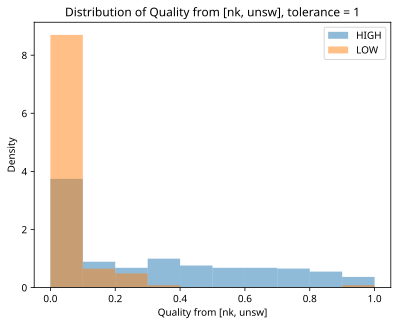

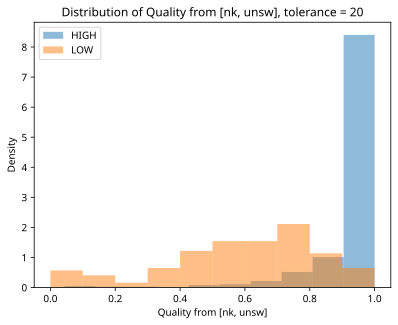

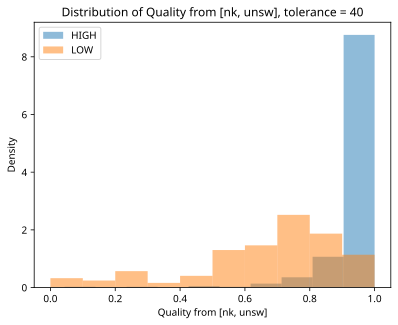

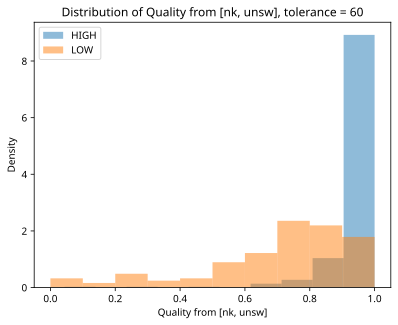

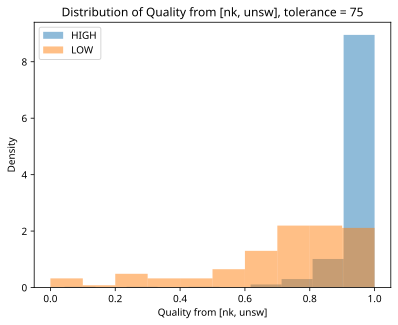

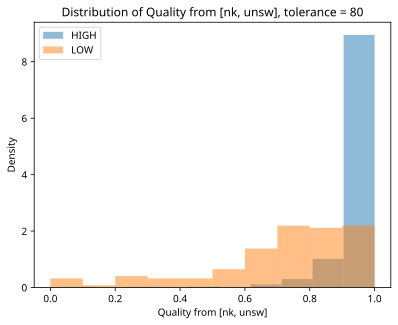

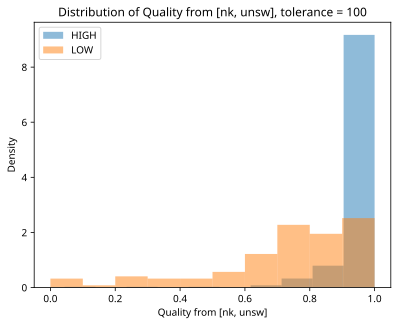

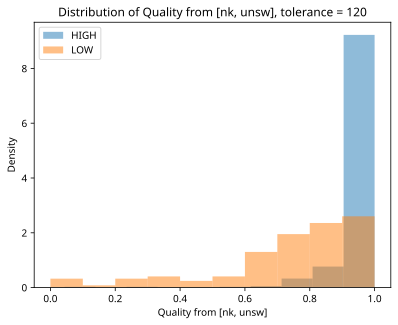

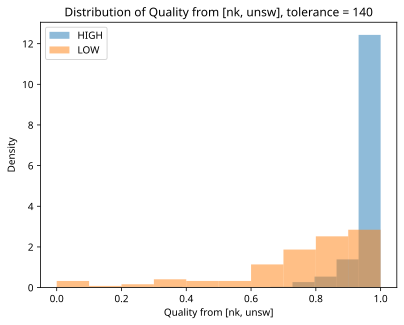

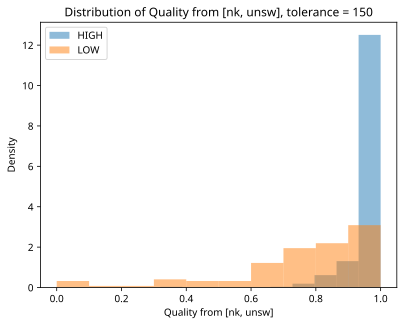

In [158]:
for safer_quality_HIGH_nk_unsw, safer_quality_LOW_nk_unsw, i in zip(safer_quality_HIGH_nk_unsw_tolerance, safer_quality_LOW_nk_unsw_tolerance, tolerance_window_size_list):
    plt.figure()
    plt.hist(safer_quality_HIGH_nk_unsw, alpha=0.5, label = 'HIGH', density = True)
    plt.hist(safer_quality_LOW_nk_unsw, alpha=0.5, label = 'LOW', density = True)
    plt.title(f'Distribution of Quality from [nk, unsw], tolerance = {i}')
    plt.xlabel('Quality from [nk, unsw]')
    plt.ylabel('Density')
    plt.legend()

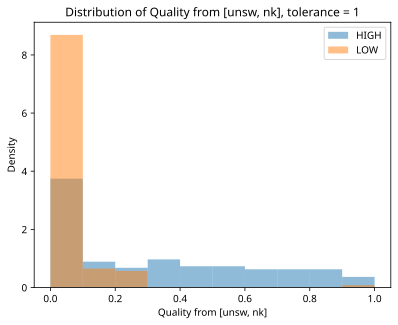

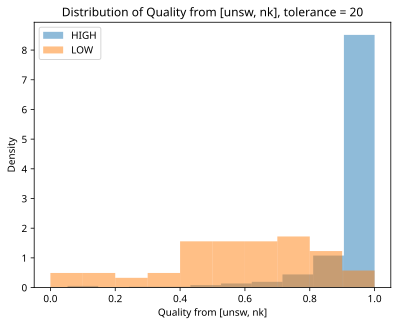

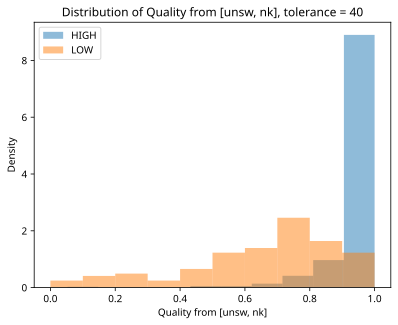

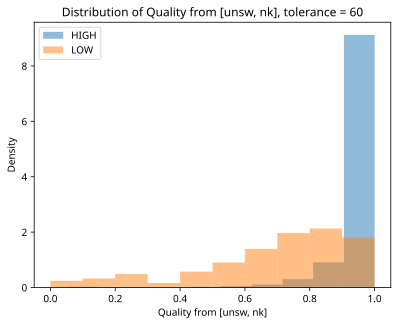

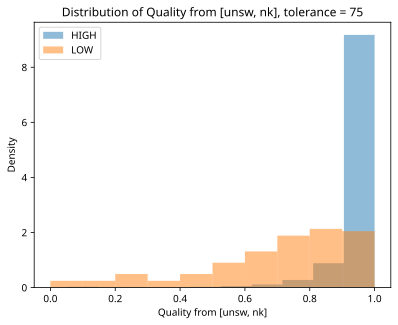

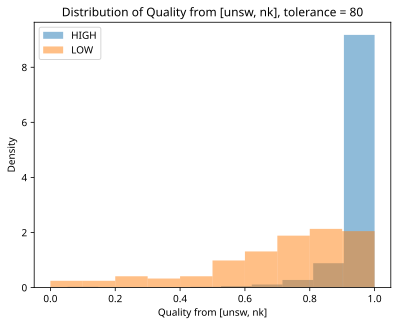

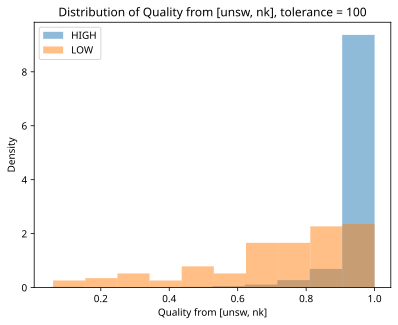

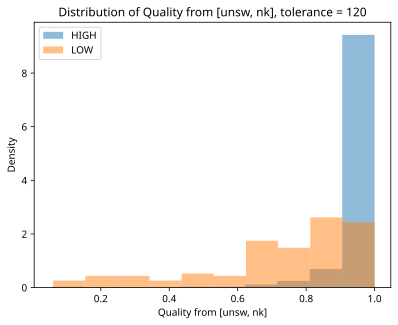

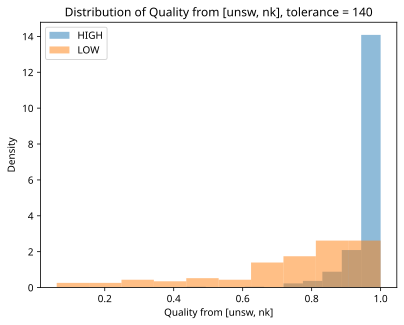

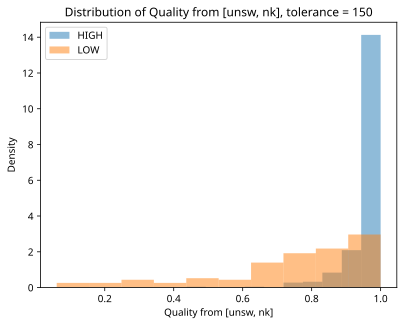

In [159]:
for safer_quality_HIGH_unsw_nk, safer_quality_LOW_unsw_nk, i in zip(safer_quality_HIGH_unsw_nk_tolerance, safer_quality_LOW_unsw_nk_tolerance, tolerance_window_size_list):
    plt.figure()
    plt.hist(safer_quality_HIGH_unsw_nk, alpha=0.5, label = 'HIGH', density = True)
    plt.hist(safer_quality_LOW_unsw_nk, alpha=0.5, label = 'LOW', density = True)
    plt.title(f'Distribution of Quality from [unsw, nk], tolerance = {i}')
    plt.xlabel('Quality from [unsw, nk]')
    plt.ylabel('Density')
    plt.legend()

In [163]:
np.mean([70,89,89.4,77])

81.35

It will be interesting to explore the readings that are labelled as LOW but is deemed high quality with the tool

In [466]:
indices_low90_unsw_nk = [index for index, (binary, num) in enumerate(zip(safer_cardiolund_label_binary, safer_quality_unsw_nk)) if num >= 0.9 and binary == 0]

indices_low90_nk_unsw = [index for index, (binary, num) in enumerate(zip(safer_cardiolund_label_binary, safer_quality_nk_unsw)) if num >= 0.9 and binary == 0]

print(len(indices_low90_unsw_nk))
print(len(indices_low90_nk_unsw))

print(set(indices_low90_unsw_nk) - set(indices_low90_nk_unsw))
print(set(indices_low90_nk_unsw) - set(indices_low90_unsw_nk))

35
37
{61, 285, 398}
{385, 390, 141, 277, 378}


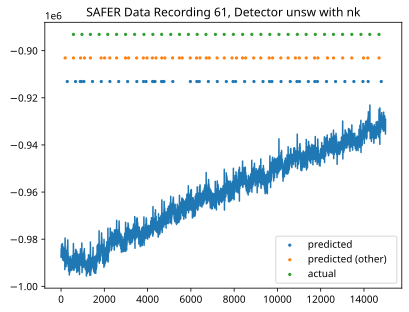

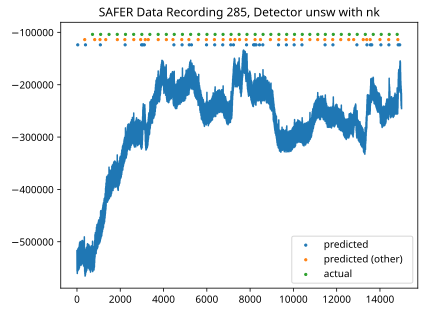

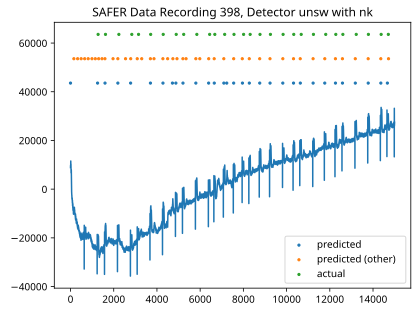

In [468]:
obj_safer = pd.read_pickle(r'pickle/safer_trial_database_evaluated.pkl')
recording_numbers = [61, 285, 398]
detector_numbers_other = -2
detector_numbers = [-1]
for recording_number in recording_numbers:
    for detector_number in detector_numbers:
        actual_qrs = obj_safer.Users[recording_number].Recordings[0].WholeActual_Qrs_Complex
        predicted_qrs = obj_safer.Users[recording_number].Recordings[0].Evaluations[detector_number].predicted_peaks #each Evaluation is result from one detector 
        actual_signal = obj_safer.Users[recording_number].Recordings[0].WholeSignal
        predicted_qrs_other = obj_safer.Users[recording_number].Recordings[0].Evaluations[detector_numbers_other].predicted_peaks #each Evaluation is result from one detector 
        ys_predicted = [np.max(actual_signal)+10000 for i in range(len(predicted_qrs))]
        ys_predicted_other = [np.max(actual_signal)+20000 for i in range(len(predicted_qrs_other))]
        ys_actual = [np.max(actual_signal)+30000 for i in range(len(actual_qrs))]
        plt.figure()
        plt.scatter(predicted_qrs, ys_predicted, s = 5, label = 'predicted')
        plt.scatter(predicted_qrs_other, ys_predicted_other, s = 5, label = 'predicted (other)')
        plt.scatter(actual_qrs, ys_actual, s = 5, label = 'actual')
        plt.title(f'SAFER Data Recording {recording_number}, Detector {detectors_base[detector_number].short_name} with {detectors_other[detector_numbers_other].short_name}')
        plt.plot(actual_signal)
        plt.legend()